In [5]:
!conda create -n pycaret_env python=3.10
!conda activate pycaret_env
!pip install pycaret

<frozen importlib._bootstrap>:488: Warning: OpenSSL 3's legacy provider failed to load. Legacy algorithms will not be available. If you need those algorithms, check your OpenSSL configuration.
Do you accept the Terms of Service (ToS) for https://repo.anaconda.com/pkgs/r? 
[(a)ccept/(r)eject/(v)iew]: 
CondaError: KeyboardInterrupt

^C
<frozen importlib._bootstrap>:488: Warning: OpenSSL 3's legacy provider failed to load. Legacy algorithms will not be available. If you need those algorithms, check your OpenSSL configuration.

CondaError: Run 'conda init' before 'conda activate'

Defaulting to user installation because normal site-packages is not writeable
  Using cached pycaret-3.3.2-py3-none-any.whl.metadata (17 kB)
  Using cached numpy-1.26.4-cp313-cp313-linux_x86_64.whl
  Using cached pandas-2.1.4.tar.gz (4.3 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... e

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import PowerTransformer, StandardScaler

from imblearn.combine import SMOTEENN

from pycaret.regression import *
from pycaret.internal.preprocess.transformers import TransformerWrapper


import pandas as pd

import joblib # For store the PowerTrasnformers

ModuleNotFoundError: No module named 'pycaret'

### Innits


In [3]:
## GK
## ---> >60  = 2
## ---> cs*4
## ---> ((sv)/3)*1
## ---> gc
## ---> yc*-1


## DEF
## ---> >60  = 2
## ---> xg*6
## ---> xa*3
## ---> cs*4
## ---> gc
## ---> yc*-1


## MID
## ---> >60  = +2
## ---> xg*5
## ---> xa*3
## ---> cs*1
## ---> yc*-1


## FWD
## ---> >60  = 2
## ---> xg*4
## ---> xa*3
## ---> yc*-1

data_23_24

,Unnamed: 0,assists_x,bonus,bps,clean_sheets,creativity,element,expected_assists,expected_goal_involvements,expected_goals,...,npxG_5,xGChain_5,xGBuildup_5,xP_5,ownership_change,percenatge_net_transfers,pts_bps,whh,whd,wha
0,0,0,0,0,0,0.0,127,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,0.0,-1.000000,0.0,0.441,0.271,0.288
1,1,0,0,0,0,0.0,127,0.0,0.0,0.0,...,0.0,0.00,0.00,0.00,-108.0,-1.000000,0.0,0.506,0.260,0.234
2,2,0,0,0,0,0.0,127,0.0,0.0,0.0,...,0.0,0.00,0.00,0.00,-314.0,-1.000000,0.0,0.565,0.236,0.199
3,3,0,0,0,0,0.0,127,0.0,0.0,0.0,...,0.0,0.05,0.04,0.00,-15.0,-1.000000,0.0,0.382,0.265,0.353
4,4,0,0,0,0,0.0,127,0.0,0.0,0.0,...,0.0,0.05,0.04,0.00,-23.0,-1.000000,0.0,0.577,0.212,0.212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11289,11341,0,2,28,1,0.0,687,0.0,0.0,0.0,...,0.0,0.13,0.13,2.70,0.0,0.784761,7.0,0.438,0.248,0.314
11290,11342,0,0,31,1,0.0,687,0.0,0.0,0.0,...,0.0,0.13,0.13,3.78,78921.0,0.819526,6.0,0.577,0.212,0.212
11291,11343,0,0,12,0,0.0,687,0.0,0.0,0.0,...,0.0,0.17,0.17,4.44,343317.0,0.928148,1.0,0.278,0.249,0.473
11292,11344,0,0,14,0,0.0,687,0.0,0.0,0.0,...,0.0,0.07,0.07,5.36,0.0,0.928148,2.0,0.284,0.235,0.481


In [2]:
gw=35

data_23_24 = pd.read_csv('./data/joint/23-24/merged_player_data.csv') #.dropna()

data_tar = data_23_24[data_23_24['event']==gw]
data = data_23_24[data_23_24['event'] < gw]
data_test = data_23_24[data_23_24['event'] > gw]


data_36 = data_test[data_test['event'] == 36]
data_37 = data_test[data_test['event'] == 37]
data_38 = data_test[data_test['event'] == 38]

data_36_gk = data_36[data_36['position'] == 'GK']
data_37_gk = data_37[data_37['position'] == 'GK']
data_38_gk = data_38[data_38['position'] == 'GK']

data_36_def = data_36[data_36['position'] == 'DEF']
data_37_def = data_37[data_37['position'] == 'DEF']
data_38_def = data_38[data_38['position'] == 'DEF']


data_36_mid = data_36[data_36['position'] == 'MID']
data_37_mid = data_37[data_37['position'] == 'MID']
data_38_mid = data_38[data_38['position'] == 'MID']


data_36_fwd = data_36[data_36['position'] == 'FWD']
data_37_fwd = data_37[data_37['position'] == 'FWD']
data_38_fwd = data_38[data_38['position'] == 'FWD']

In [4]:
features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'ownership_change', 'percenatge_net_transfers',

            'clean_sheets', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'goals_conceded', 'goals_scored', 'ict_index',
            'influence', 'creativity', 'threat', 'minutes', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'yellow_cards', 'saves', 'starts',
            'team_a_score', 'team_h_score', 'total_points', 'goals', 'shots', 'xG', 'xA', 'assists_x', 'assists_y', 'key_passes', 'npg', 'npxG', 'xGChain',  'xGBuildup',  'xP',

            'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_missed_1', 'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1', 'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1',
            'xGBuildup_1',  'xP_1',

            'clean_sheets_2', 'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'goals_scored_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_missed_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'assists_y_2', 'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2',
            'xGBuildup_2',  'xP_2',

            'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3',
            'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'goals_scored_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_missed_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'assists_y_4', 'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4',
            'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5', 'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5',
            'xGBuildup_5',  'xP_5'
                        ]

# Goals


## Def


In [5]:
def_xg_features = [ 'position',  'xG', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',

            'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1',  'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3',  'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5',  'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

xG
0.000000    1264
0.077296       1
0.109591       1
0.017859       1
0.010836       1
            ... 
0.113652       1
0.127806       1
0.016352       1
0.012572       1
0.102933       1
Name: count, Length: 753, dtype: int64


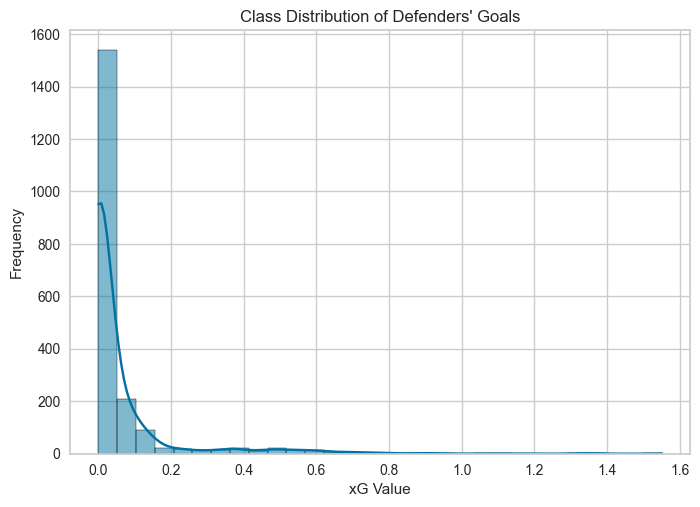

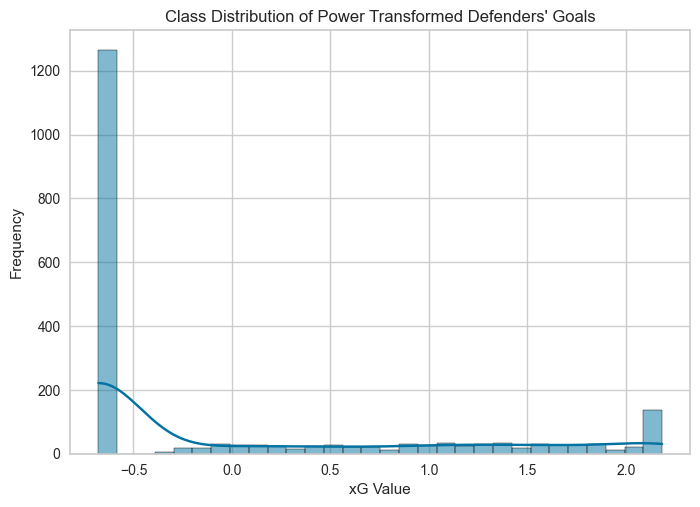

In [6]:
## TODO: XG PER 90????
def_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_xg_data = def_data[def_xg_features]
def_xg_data_tar = def_data_tar[def_xg_features]

def_data.reset_index(drop=True, inplace=True)
def_xg_data.reset_index(drop=True, inplace=True)

def_xg_data.drop(columns=['position'], inplace=True)
def_xg_data_tar.drop(columns=['xG', 'position'], inplace=True)

print(def_xg_data['xG'].value_counts())

sns.histplot(data=def_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=def_xg_data)
plt.title('Class Distribution of Defenders\' Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

pt_def_xg = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_def_xg.fit(def_xg_data[['xG']])
joblib.dump(pt_def_xg, './models/pt_def_xg.pkl')  # Save fitted transformer

def_xg_data['xG'] = pt_def_xg.transform(def_xg_data[['xG']])


sns.histplot(data=def_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=def_xg_data)
plt.title('Class Distribution of Power Transformed Defenders\' Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


In [7]:
def_xg_data

,xG,whh,whd,wha,was_home,team_h_difficulty,team_a_difficulty,percenatge_net_transfers,ict_index,influence,...,xG_5,xA_5,assists_x_5,assists_y_5,key_passes_5,npg_5,npxG_5,xGChain_5,xGBuildup_5,xP_5
0,1.276481,0.618,0.225,0.157,False,2,4,-0.383192,3.2,10.0,...,0.01,0.01,0.0,0.0,0.2,0.0,0.01,0.12,0.12,1.76
1,0.604458,0.526,0.249,0.225,True,2,2,0.639204,0.6,0.0,...,0.02,0.01,0.0,0.0,0.2,0.0,0.02,0.14,0.12,1.92
2,-0.677699,0.344,0.305,0.351,False,2,2,-0.402459,0.7,2.0,...,0.03,0.00,0.0,0.0,0.0,0.0,0.03,0.15,0.13,1.76
3,0.738821,0.572,0.227,0.201,False,2,4,-0.544130,0.0,0.0,...,0.03,0.00,0.0,0.0,0.0,0.0,0.03,0.13,0.11,1.46
4,-0.677699,0.579,0.239,0.182,False,2,3,-0.490372,2.0,15.6,...,0.04,0.00,0.0,0.0,0.0,0.0,0.04,0.10,0.08,1.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2011,1.973701,0.431,0.306,0.263,False,2,2,-0.067259,3.1,22.0,...,0.13,0.06,0.0,0.0,0.2,0.2,0.13,0.09,0.03,2.38
2012,1.552652,0.572,0.255,0.174,True,2,2,0.772846,2.0,12.2,...,0.12,0.06,0.0,0.0,0.2,0.2,0.12,0.22,0.15,2.68
2013,-0.677699,0.745,0.167,0.087,False,2,5,-0.113902,4.0,27.0,...,0.11,0.06,0.0,0.0,0.2,0.0,0.11,0.27,0.22,3.22
2014,-0.677699,0.506,0.260,0.234,False,2,3,-0.286458,1.0,7.8,...,0.11,0.07,0.0,0.0,0.4,0.0,0.11,0.27,0.22,3.08


In [8]:
base_def_xg_model = setup(def_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_def_xg_best = base_def_xg_model.compare_models(sort='MAE', n_select=1)
base_def_xg_best

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003348 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5077
[LightGBM] [Info] Number of data points in the train set: 1612, number of used features: 69
[LightGBM] [Info] Start training from score 0.009218


,Description,Value
0,Session id,1832
1,Target,xG
2,Target type,Regression
3,Original data shape,"(2016, 93)"
4,Transformed data shape,"(2016, 19)"
5,Transformed train set shape,"(1612, 19)"
6,Transformed test set shape,"(404, 19)"
7,Numeric features,91
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.3191,0.2915,0.5392,0.7085,0.2395,1.1857,1.2890
rf,Random Forest Regressor,0.3255,0.3074,0.5539,0.6918,0.2477,1.1740,1.5870
gbr,Gradient Boosting Regressor,0.3559,0.3157,0.5611,0.6842,0.2518,1.1820,1.0770
xgboost,Extreme Gradient Boosting,0.3721,0.3649,0.6035,0.6347,0.2600,1.2557,0.9300
lightgbm,Light Gradient Boosting Machine,0.3744,0.3584,0.5982,0.6412,0.2569,1.2640,0.8600
dt,Decision Tree Regressor,0.4031,0.5822,0.7611,0.4144,0.2711,1.6650,0.8880
ada,AdaBoost Regressor,0.4173,0.3510,0.5899,0.6486,0.2550,1.2664,0.8790
huber,Huber Regressor,0.4295,0.4960,0.7027,0.5073,0.3183,0.9120,0.7460
knn,K Neighbors Regressor,0.4651,0.4902,0.6993,0.5117,0.3103,1.1184,0.8680
br,Bayesian Ridge,0.5044,0.4589,0.6763,0.5435,0.3456,0.8993,1.0490


ExtraTreesRegressor(n_jobs=-1, random_state=1832)

In [9]:
evaluate_model(base_def_xg_best)
# plot_model(base_fwd_y_best, plot='confusion_matrix')

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

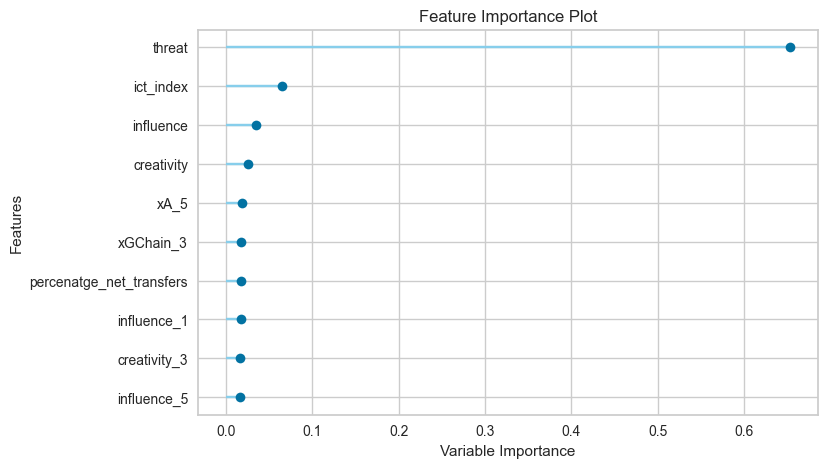

In [10]:
# plot_model(base_def_xg_best, plot='residuals')      # Residuals vs. predicted values
# plot_model(base_def_xg_best, plot='error')          # Prediction error plot
plot_model(base_def_xg_best, plot='feature')        # Feature importance

### Tune Model


In [11]:
def_xg_tuned = tune_model(base_def_xg_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.4281,0.6190,0.7868,0.4248,0.3179,0.7631
1,0.4170,0.5829,0.7635,0.4433,0.2729,0.8296
2,0.3901,0.5358,0.7320,0.4541,0.2679,0.6097
3,0.4498,0.6280,0.7924,0.3593,0.2939,0.7329
4,0.4378,0.6355,0.7972,0.4758,0.2927,1.9556
5,0.4405,0.5345,0.7311,0.5123,0.2840,0.9467
6,0.3454,0.4267,0.6532,0.4735,0.2314,1.4197
7,0.4066,0.5874,0.7664,0.3461,0.2739,1.7129
8,0.4086,0.4770,0.6906,0.5277,0.2768,0.7794


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [12]:
# Apply patch
# TransformerWrapper._reorder_cols = _reorder_cols
def_xg_final_model = finalize_model(base_def_xg_best)
save_model(def_xg_final_model, './models/def_xg_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'expected_goals_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_1', 'creativi...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',
 

## Mid


In [13]:
mid_xg_features = [ 'position',  'xG', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',

            'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1',  'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3',  'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5',  'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

xG
0.000000    679
0.761169      8
0.506165      1
0.683797      1
0.118155      1
           ... 
0.092947      1
0.060066      1
0.016371      1
0.101588      1
0.121570      1
Name: count, Length: 1382, dtype: int64


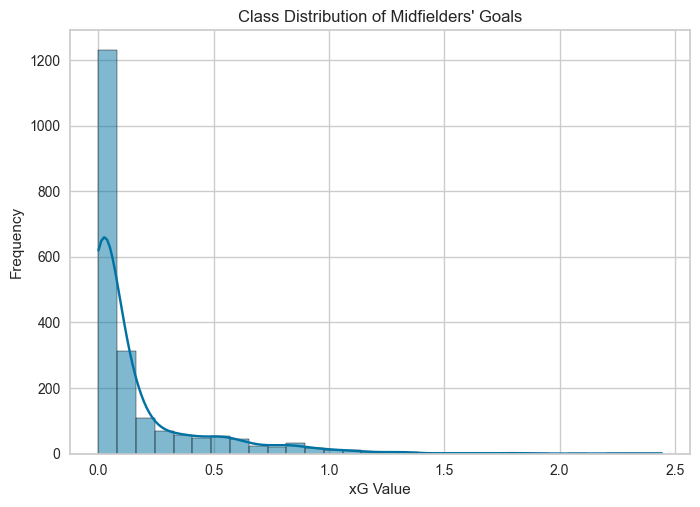

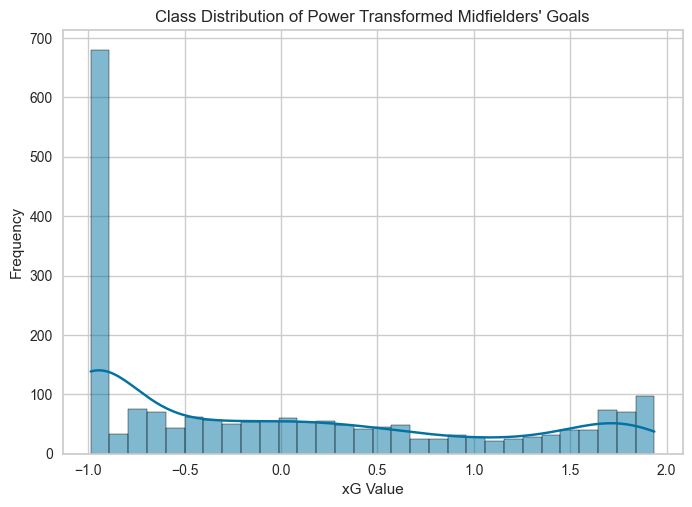

In [14]:

mid_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_xg_data = mid_data[mid_xg_features]
mid_xg_data_tar = mid_data_tar[mid_xg_features]

mid_data.reset_index(drop=True, inplace=True)
mid_xg_data.reset_index(drop=True, inplace=True)

mid_xg_data.drop(columns=['position'], inplace=True)
mid_xg_data_tar.drop(columns=['xG', 'position'], inplace=True)

print(mid_xg_data['xG'].value_counts())

sns.histplot(data=mid_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=mid_xg_data)
plt.title('Class Distribution of Midfielders\' Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

pt_mid_xg = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_mid_xg.fit(mid_xg_data[['xG']])
joblib.dump(pt_mid_xg, './models/pt_mid_xg.pkl')  # Save fitted transformer

mid_xg_data['xG'] = pt_mid_xg.transform(mid_xg_data[['xG']])


sns.histplot(data=mid_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=mid_xg_data)
plt.title('Class Distribution of Power Transformed Midfielders\' Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


In [15]:
base_mid_xg_model = setup(mid_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_mid_xg_best = base_mid_xg_model.compare_models(sort='MAE')
base_mid_xg_best

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000654 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5987
[LightGBM] [Info] Number of data points in the train set: 1653, number of used features: 70
[LightGBM] [Info] Start training from score -0.015524


,Description,Value
0,Session id,7036
1,Target,xG
2,Target type,Regression
3,Original data shape,"(2067, 93)"
4,Transformed data shape,"(2067, 19)"
5,Transformed train set shape,"(1653, 19)"
6,Transformed test set shape,"(414, 19)"
7,Numeric features,91
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3626,0.2753,0.5243,0.7209,0.2669,1.7068,1.6630
et,Extra Trees Regressor,0.3648,0.2736,0.5226,0.7226,0.2608,1.7524,1.2580
gbr,Gradient Boosting Regressor,0.3704,0.2716,0.5209,0.7247,0.2676,1.6594,1.2040
lightgbm,Light Gradient Boosting Machine,0.3768,0.2892,0.5373,0.7071,0.2667,1.8568,1.4420
xgboost,Extreme Gradient Boosting,0.3962,0.3127,0.5584,0.6828,0.2720,1.9033,1.1750
ada,AdaBoost Regressor,0.4262,0.2970,0.5446,0.6984,0.2673,1.7802,0.9740
huber,Huber Regressor,0.4464,0.3856,0.6202,0.6083,0.2853,1.6150,0.7940
knn,K Neighbors Regressor,0.4534,0.3769,0.6132,0.6171,0.2973,1.9240,0.8140
lr,Linear Regression,0.4638,0.3635,0.6023,0.6308,0.2958,1.4813,0.7100
ridge,Ridge Regression,0.4640,0.3636,0.6023,0.6308,0.2953,1.4859,0.7780


RandomForestRegressor(n_jobs=-1, random_state=7036)

In [16]:
evaluate_model(base_mid_xg_best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

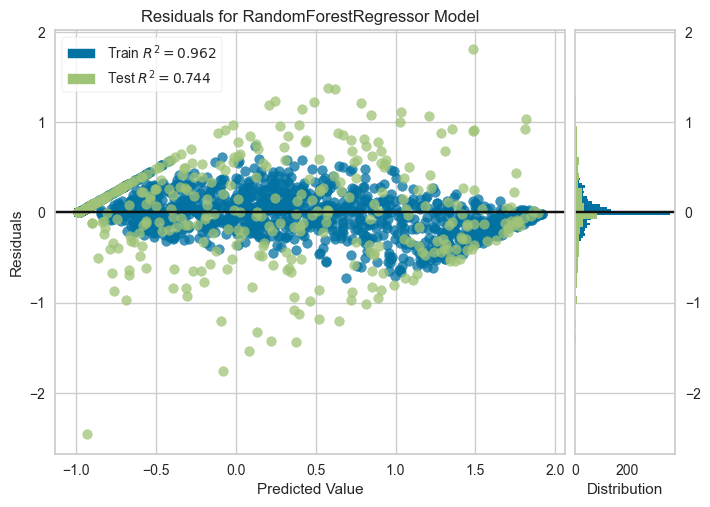

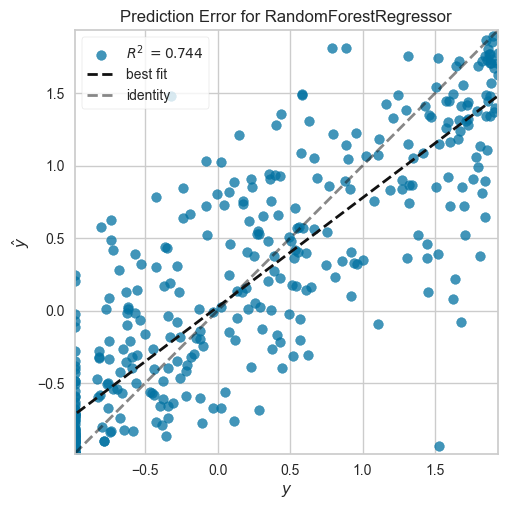

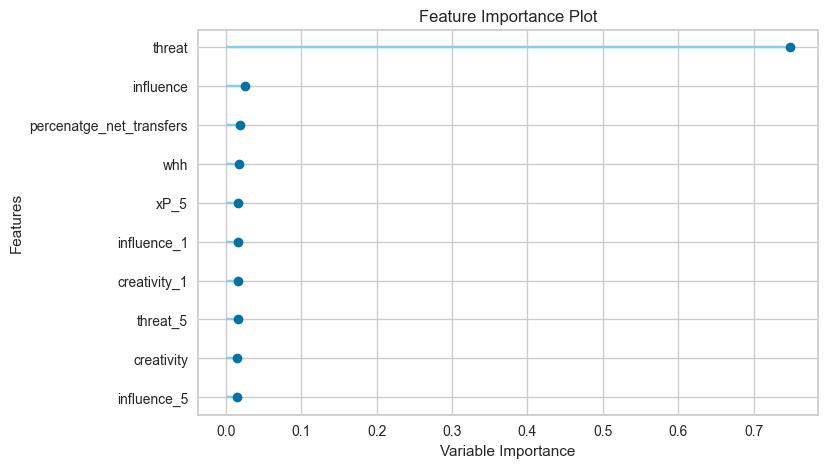

In [17]:
plot_model(base_mid_xg_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_mid_xg_best, plot='error')          # Prediction error plot
plot_model(base_mid_xg_best, plot='feature')        # Feature importance

### Tune Model


In [18]:
mid_xg_tuned = tune_model(base_mid_xg_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3638,0.2863,0.5350,0.6915,0.2736,1.1749
1,0.3773,0.3352,0.5790,0.6797,0.2801,1.2450
2,0.3246,0.2708,0.5204,0.7067,0.2626,2.3812
3,0.3312,0.3124,0.5589,0.6775,0.2422,3.0311
4,0.3641,0.3141,0.5604,0.6912,0.2585,2.8412
5,0.3462,0.2692,0.5189,0.7360,0.2732,1.6007
6,0.3591,0.2970,0.5449,0.6895,0.2573,2.3782
7,0.3579,0.3134,0.5598,0.6948,0.2627,1.2200
8,0.3584,0.2818,0.5309,0.7257,0.2794,3.2652


Fitting 10 folds for each of 10 candidates, totalling 100 fits


### Save Model


In [19]:
mid_xg_final_model = finalize_model(base_mid_xg_best)
save_model(mid_xg_final_model, './models/mid_xg_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'expected_goals_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_1', 'creativi...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',
 

## For


xG
0.000000    94
0.100277     1
0.546682     1
0.141245     1
0.410759     1
            ..
0.823317     1
0.134095     1
0.162047     1
1.774810     1
0.371195     1
Name: count, Length: 402, dtype: int64


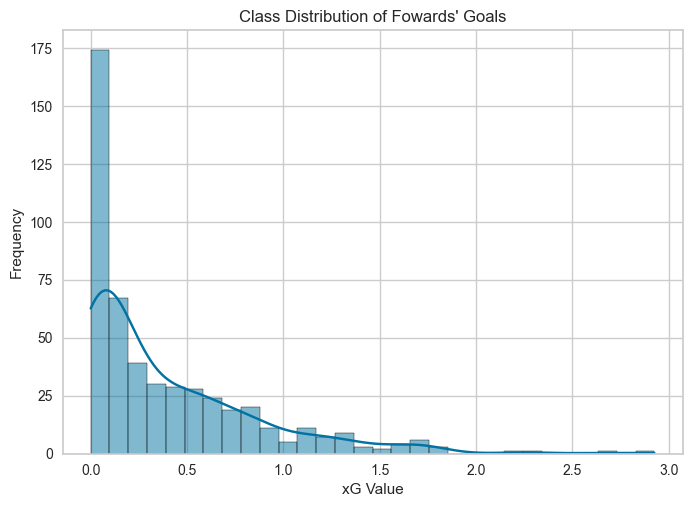

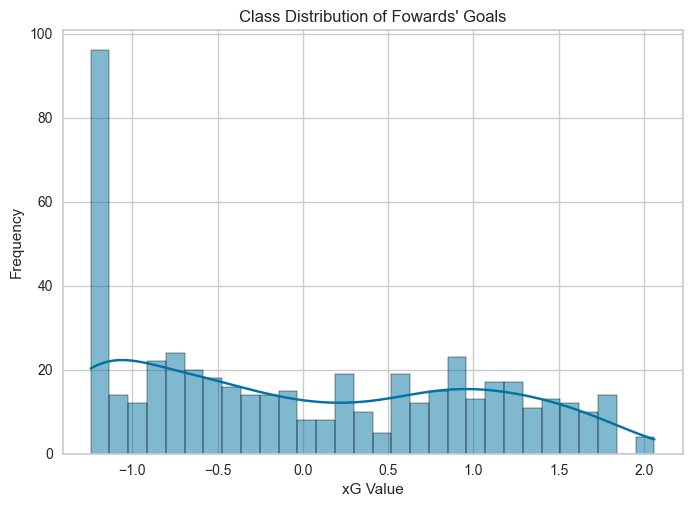

In [20]:
f_xg_features = [ 'position',  'xG', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',


            'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1',  'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3',  'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5',  'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]



fwd_xg_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'FWD')]
fwd_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '4')]

fwd_xg_data = fwd_xg_data[f_xg_features]
fwd_xg_data_tar = fwd_data_tar[f_xg_features]

fwd_xg_data.reset_index(drop=True, inplace=True)
fwd_xg_data.reset_index(drop=True, inplace=True)

fwd_xg_data.drop(columns=['position'], inplace=True)
fwd_xg_data_tar.drop(columns=['xG', 'position'], inplace=True)

print(fwd_xg_data['xG'].value_counts())

sns.histplot(data=fwd_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=fwd_xg_data)
plt.title('Class Distribution of Fowards\' Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

pt_fwd_xg = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_fwd_xg.fit(fwd_xg_data[['xG']])
joblib.dump(pt_fwd_xg, './models/pt_fwd_xg.pkl')  # Save fitted transformer

fwd_xg_data['xG'] = pt_fwd_xg.transform(fwd_xg_data[['xG']])


sns.histplot(data=fwd_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=fwd_xg_data)
plt.title('Class Distribution of Fowards\' Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()


### Base Model


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007245 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2491
[LightGBM] [Info] Number of data points in the train set: 396, number of used features: 61
[LightGBM] [Info] Start training from score 0.022654
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

,Description,Value
0,Session id,8851
1,Target,xG
2,Target type,Regression
3,Original data shape,"(495, 93)"
4,Transformed data shape,"(495, 19)"
5,Transformed train set shape,"(396, 19)"
6,Transformed test set shape,"(99, 19)"
7,Numeric features,91
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.4423,0.3311,0.5703,0.6437,0.2673,1.0273,0.4320
rf,Random Forest Regressor,0.4452,0.3328,0.5730,0.6415,0.2746,0.9601,0.6330
gbr,Gradient Boosting Regressor,0.4505,0.3392,0.5775,0.6334,0.2610,1.0346,0.4480
lightgbm,Light Gradient Boosting Machine,0.4558,0.3544,0.5913,0.6179,0.2637,1.0804,0.2960
knn,K Neighbors Regressor,0.4688,0.3737,0.6069,0.5966,0.2687,0.9508,0.2450
xgboost,Extreme Gradient Boosting,0.4721,0.3774,0.6107,0.5920,0.2756,1.2283,0.3850
huber,Huber Regressor,0.4832,0.3853,0.6136,0.5849,0.2740,1.1296,0.4130
ridge,Ridge Regression,0.4965,0.3695,0.6025,0.6019,0.2838,1.0996,0.6060
br,Bayesian Ridge,0.4981,0.3673,0.6016,0.6062,0.2821,0.9907,0.2570
lr,Linear Regression,0.4986,0.3731,0.6054,0.5976,0.2854,1.1226,0.5940


ExtraTreesRegressor(n_jobs=-1, random_state=8851)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


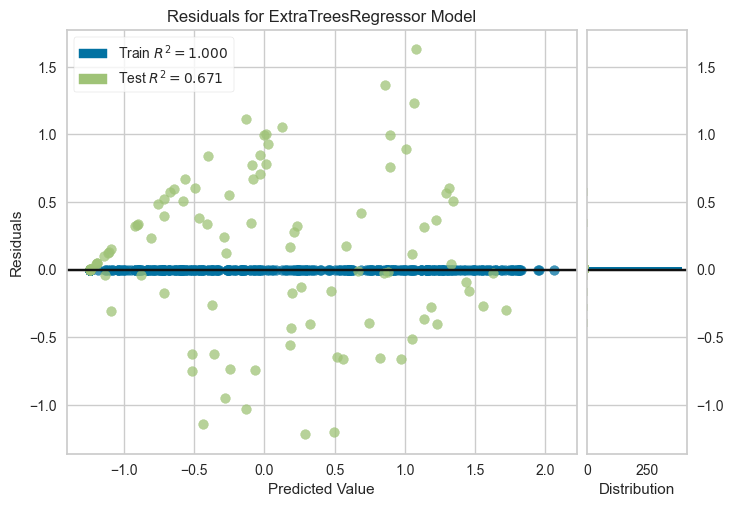

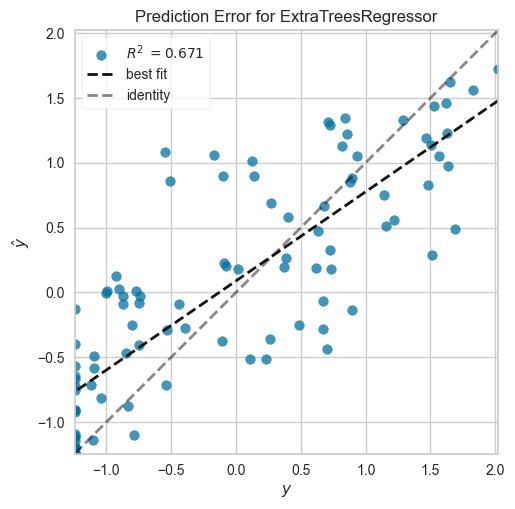

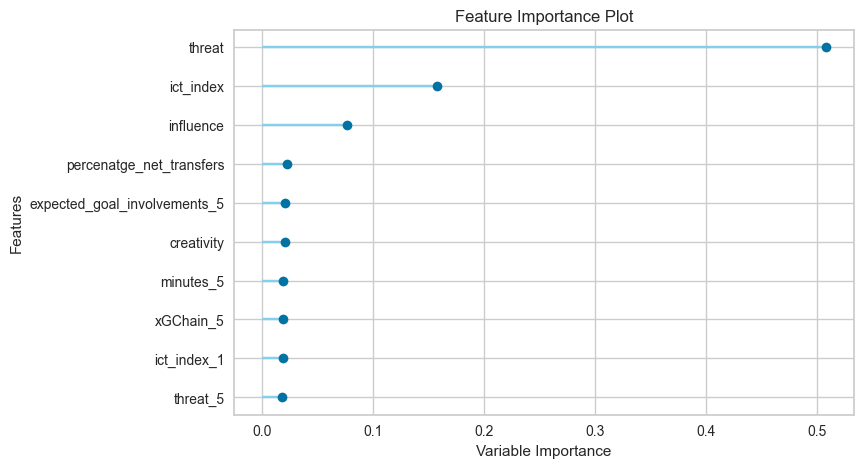

In [21]:
base_fwd_xg_model = setup(fwd_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_fwd_xg_best = base_fwd_xg_model.compare_models(sort='MAE', n_select=1)
print(base_fwd_xg_best)

print('Évaluate the model...')
evaluate_model(base_fwd_xg_best)

print('Plots...')
plot_model(base_fwd_xg_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_fwd_xg_best, plot='error')          # Prediction error plot
plot_model(base_fwd_xg_best, plot='feature')        # Feature importance



### Tune Model


In [22]:
tuned_fwd_xg_model = tune_model(base_fwd_xg_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.4477,0.3789,0.6155,0.5385,0.2442,0.7911
1,0.4310,0.2918,0.5402,0.7339,0.2951,0.9221
2,0.3511,0.2273,0.4768,0.6926,0.2318,0.8067
3,0.4541,0.3392,0.5824,0.5731,0.2612,0.7531
4,0.5369,0.4743,0.6887,0.5030,0.2553,0.8726
5,0.5080,0.4275,0.6538,0.4718,0.2618,1.7071
6,0.4306,0.2993,0.5470,0.7564,0.2587,1.0639
7,0.4234,0.2811,0.5301,0.7601,0.2716,0.5539
8,0.3289,0.1949,0.4415,0.7933,0.2376,1.2447


Fitting 10 folds for each of 10 candidates, totalling 100 fits


### Save Model


In [23]:
fwd_xg_final_model = finalize_model(tuned_fwd_xg_model)
save_model(fwd_xg_final_model, './models/fwd_xg_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'expected_goals_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_1', 'creativi...
                  TransformerWrapper(exclude=[],
                                     transformer=RemoveMulticollinearity(threshold=0.9))),

# Assists


In [24]:
xa_features = [ 'position',  'xA', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence',
                 'creativity', 'threat','starts',

            'expected_assists_1', 'expected_goal_involvements_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1',  'shots_1','xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_3', 'expected_goal_involvements_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'shots_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_5', 'expected_goal_involvements_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'shots_5',  'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

## Def


xA
0.000000    1337
0.032433       1
0.059828       1
0.047993       1
0.754707       1
            ... 
0.179364       1
0.288245       1
0.017075       1
0.019116       1
0.055309       1
Name: count, Length: 680, dtype: int64


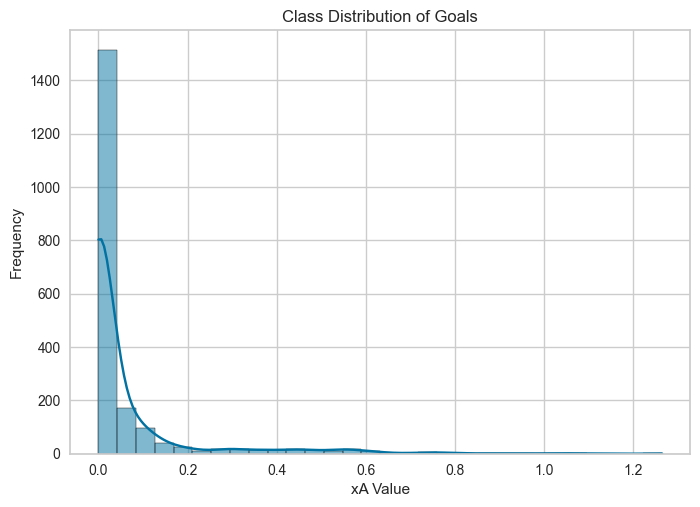

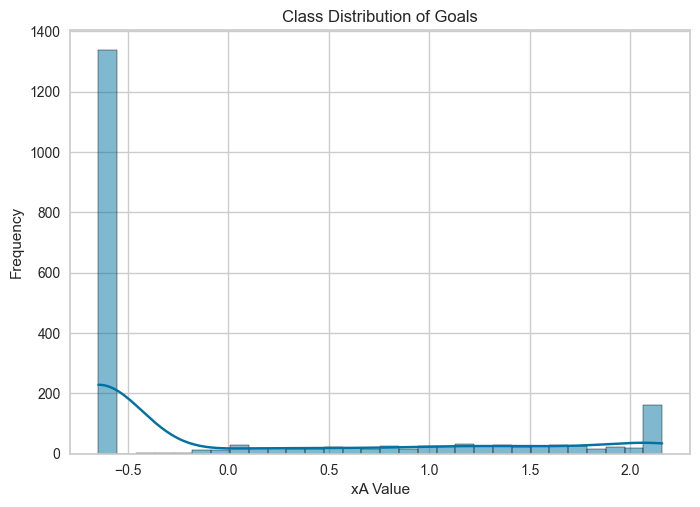

In [25]:
def_xa_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_xa_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_xa_data = def_xa_data[xa_features]
def_xa_data_tar = def_xa_data_tar[xa_features]

def_xa_data.reset_index(drop=True, inplace=True)
def_xa_data.reset_index(drop=True, inplace=True)

def_xa_data.drop(columns=['position'], inplace=True)
def_xa_data_tar.drop(columns=['xA', 'position'], inplace=True)

print(def_xa_data['xA'].value_counts())

sns.histplot(data=def_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=def_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

pt_def_xa = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_def_xa.fit(def_xa_data[['xA']])
joblib.dump(pt_def_xa, './models/pt_def_xa.pkl')  # Save fitted transformer

def_xa_data['xA'] = pt_def_xa.transform(def_xa_data[['xA']])


sns.histplot(data=def_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=def_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002517 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4883
[LightGBM] [Info] Number of data points in the train set: 1612, number of used features: 63
[LightGBM] [Info] Start training from score -0.001269
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,Description,Value
0,Session id,7920
1,Target,xA
2,Target type,Regression
3,Original data shape,"(2016, 76)"
4,Transformed data shape,"(2016, 16)"
5,Transformed train set shape,"(1612, 16)"
6,Transformed test set shape,"(404, 16)"
7,Numeric features,74
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.2081,0.1867,0.4315,0.8094,0.1992,1.3344,0.8610
et,Extra Trees Regressor,0.2132,0.1891,0.4342,0.8071,0.2025,1.4231,0.7890
gbr,Gradient Boosting Regressor,0.2216,0.1795,0.4229,0.8166,0.1946,1.4096,0.6820
lightgbm,Light Gradient Boosting Machine,0.2306,0.2028,0.4496,0.7929,0.2108,1.5221,0.9180
xgboost,Extreme Gradient Boosting,0.2379,0.2194,0.4676,0.7754,0.2178,1.5052,0.5970
dt,Decision Tree Regressor,0.2547,0.3194,0.5634,0.6753,0.2550,1.6658,0.3590
knn,K Neighbors Regressor,0.2596,0.2615,0.5108,0.7344,0.2352,1.1478,0.4990
ada,AdaBoost Regressor,0.2659,0.2007,0.4474,0.7956,0.2060,1.3839,0.4560
huber,Huber Regressor,0.3451,0.4051,0.6301,0.5834,0.2887,0.7145,0.7030
br,Bayesian Ridge,0.4087,0.3779,0.6111,0.6124,0.3001,0.8323,0.5530


RandomForestRegressor(n_jobs=-1, random_state=7920)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


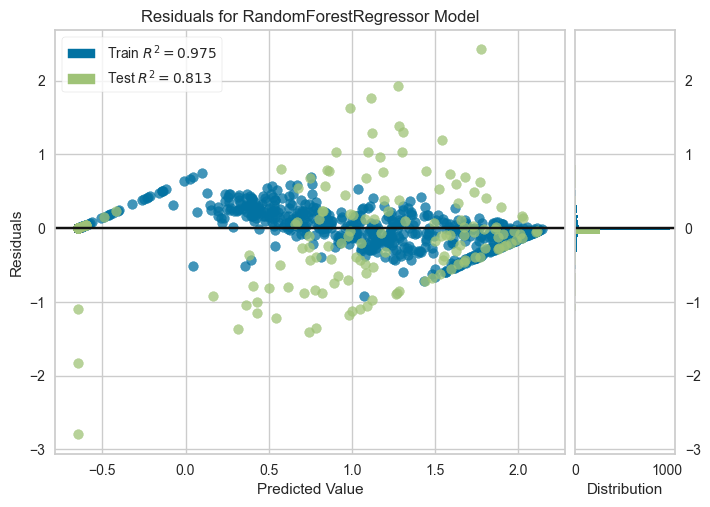

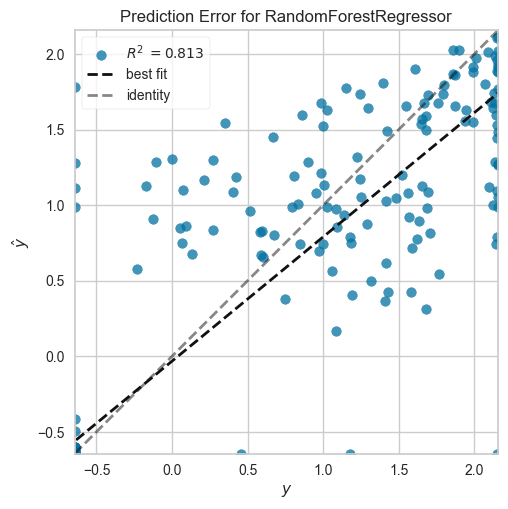

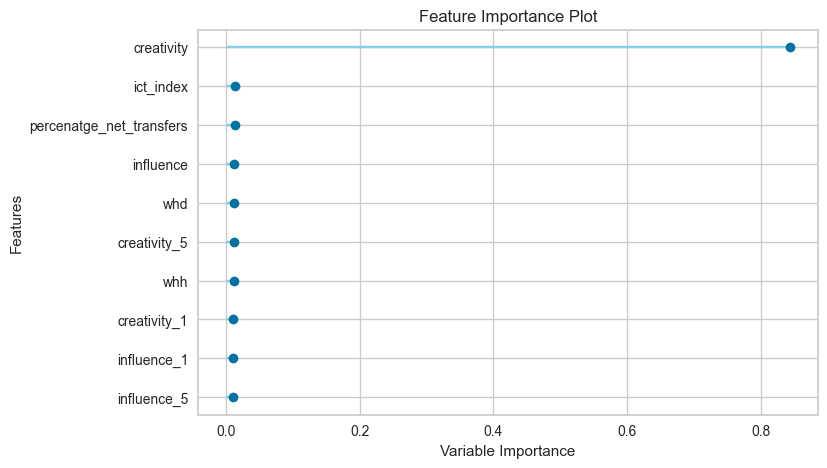

In [26]:
base_def_xa_model = setup(def_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_def_xa_best = base_def_xa_model.compare_models(sort='MAE', n_select=1)
print(base_def_xa_best)

print('Évaluate the model...')
evaluate_model(base_def_xa_best)

print('Plots...')
plot_model(base_def_xa_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_def_xa_best, plot='error')          # Prediction error plot
plot_model(base_def_xa_best, plot='feature')        # Feature importance



### Tune Model


In [27]:
def_xa_tuned = tune_model(base_def_xa_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.2075,0.2011,0.4484,0.8167,0.1757,0.3975
1,0.1983,0.1780,0.4219,0.7976,0.2007,3.2818
2,0.2353,0.2071,0.4551,0.8040,0.2055,2.0049
3,0.2057,0.1657,0.4071,0.8317,0.1966,3.0656
4,0.2260,0.2003,0.4475,0.7932,0.1920,0.4500
5,0.2372,0.2142,0.4628,0.7907,0.1989,0.9519
6,0.1832,0.1558,0.3947,0.8375,0.1741,0.8291
7,0.2087,0.1768,0.4205,0.8216,0.1962,0.7505
8,0.1914,0.1573,0.3967,0.8102,0.1758,0.7749


Fitting 10 folds for each of 10 candidates, totalling 100 fits


### Save Model


In [28]:
def_xa_final_model = finalize_model(base_def_xa_best)
save_model(def_xa_final_model, './models/def_xa_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat', 'starts',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'ict_index_1', 'influence_1',
                                              'creativity_1', 'threat_1',
                                              'minutes_1...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',


## Mid


xA
0.000000    832
0.027188      1
0.642431      1
0.083849      1
0.230657      1
           ... 
0.169858      1
0.092554      1
0.613722      1
0.020133      1
0.048324      1
Name: count, Length: 1236, dtype: int64


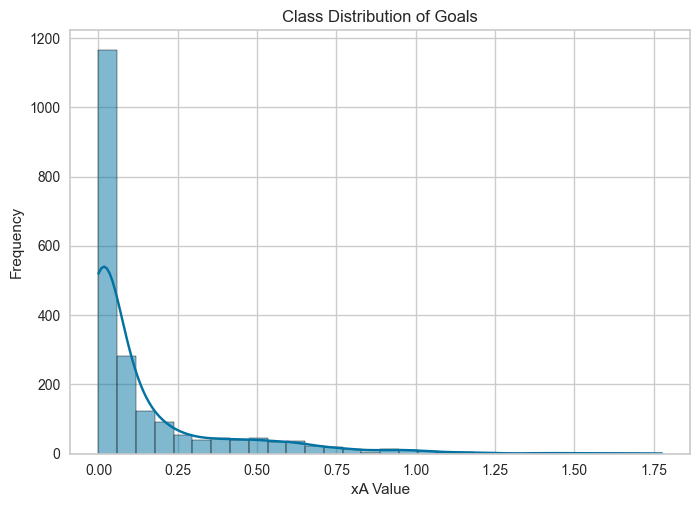

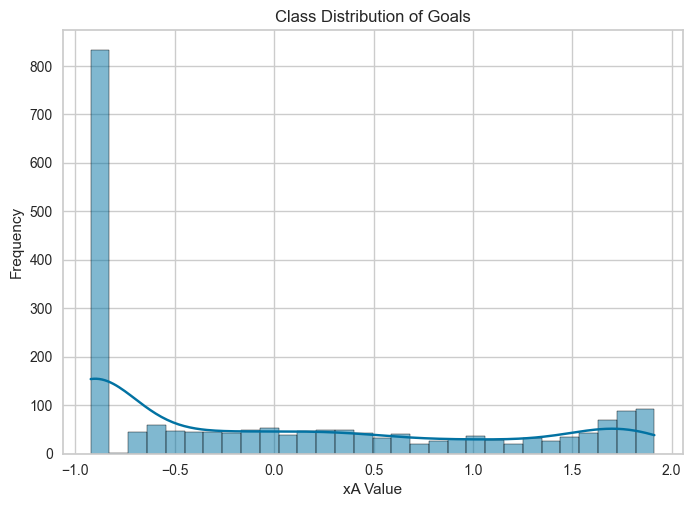

In [29]:

mid_xa_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_xa_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_xa_data = mid_xa_data[xa_features]
mid_xa_data_tar = mid_xa_data_tar[xa_features]

mid_xa_data.reset_index(drop=True, inplace=True)
mid_xa_data.reset_index(drop=True, inplace=True)

mid_xa_data.drop(columns=['position'], inplace=True)
mid_xa_data_tar.drop(columns=['xA', 'position'], inplace=True)

print(mid_xa_data['xA'].value_counts())

sns.histplot(data=mid_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=mid_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

pt_mid_xa = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_mid_xa.fit(mid_xa_data[['xA']])
joblib.dump(pt_mid_xa, './models/pt_mid_xa.pkl')  # Save fitted transformer

mid_xa_data['xA'] = pt_mid_xa.transform(mid_xa_data[['xA']])


sns.histplot(data=mid_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=mid_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

### Base model


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002195 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6232
[LightGBM] [Info] Number of data points in the train set: 1653, number of used features: 66
[LightGBM] [Info] Start training from score -0.003457


,Description,Value
0,Session id,7053
1,Target,xA
2,Target type,Regression
3,Original data shape,"(2067, 76)"
4,Transformed data shape,"(2067, 16)"
5,Transformed train set shape,"(1653, 16)"
6,Transformed test set shape,"(414, 16)"
7,Numeric features,74
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3685,0.3270,0.5702,0.6671,0.2766,1.8486,1.2480
et,Extra Trees Regressor,0.3717,0.3227,0.5668,0.6712,0.2739,1.9204,0.9830
gbr,Gradient Boosting Regressor,0.3761,0.3185,0.5627,0.6756,0.2811,1.6445,1.0620
lightgbm,Light Gradient Boosting Machine,0.3965,0.3566,0.5957,0.6370,0.2721,2.0973,0.9740
ada,AdaBoost Regressor,0.3988,0.3379,0.5792,0.6565,0.2526,2.2866,0.9290
xgboost,Extreme Gradient Boosting,0.4138,0.3786,0.6135,0.6138,0.2837,2.1802,0.8360
huber,Huber Regressor,0.4239,0.4139,0.6397,0.5825,0.2947,1.6013,0.5470
knn,K Neighbors Regressor,0.4304,0.4055,0.6342,0.5847,0.2877,1.8860,0.7040
ridge,Ridge Regression,0.4617,0.3942,0.6253,0.6008,0.3108,1.5248,0.5920
lr,Linear Regression,0.4619,0.3947,0.6258,0.6002,0.3109,1.5302,0.6640


RandomForestRegressor(n_jobs=-1, random_state=7053)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


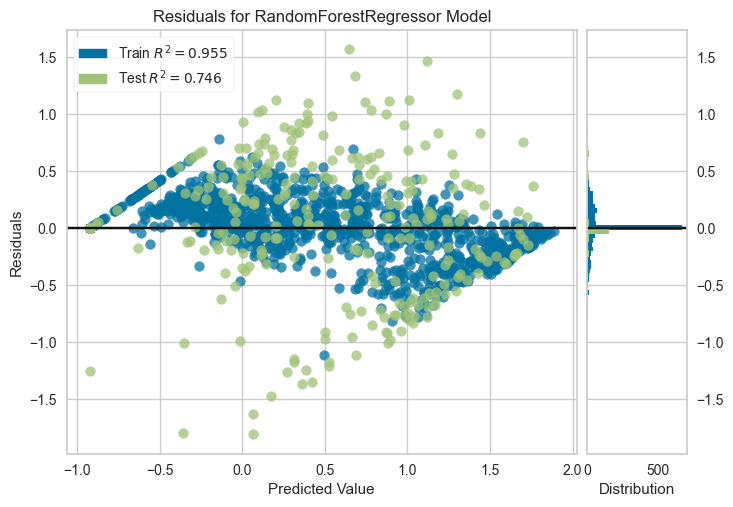

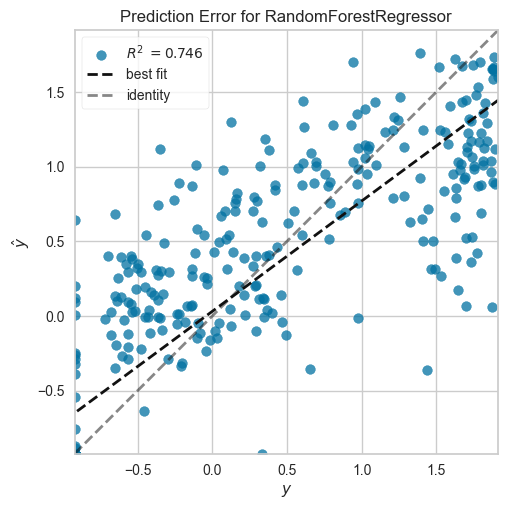

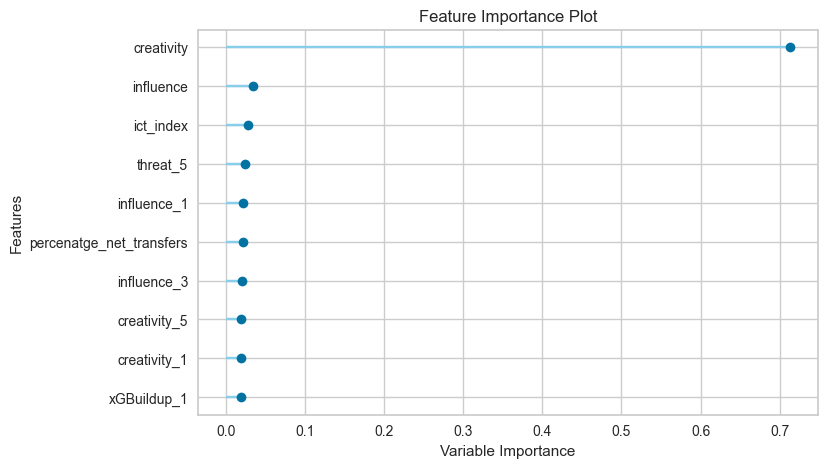

In [30]:
base_mid_xa_model = setup(mid_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_mid_xa_best = base_mid_xa_model.compare_models(sort='MAE', n_select=1)
print(base_mid_xa_best)

print('Évaluate the model...')
evaluate_model(base_mid_xa_best)

print('Plots...')
plot_model(base_mid_xa_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_mid_xa_best, plot='error')          # Prediction error plot
plot_model(base_mid_xa_best, plot='feature')        # Feature importance



### Tune model


In [31]:
mid_xa_tuned = tune_model(base_mid_xa_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3824,0.3149,0.5612,0.7149,0.2737,1.8046
1,0.2929,0.2221,0.4713,0.7009,0.2372,2.0178
2,0.3617,0.3228,0.5682,0.6785,0.2658,0.6676
3,0.4110,0.4089,0.6394,0.6066,0.3269,1.3887
4,0.3738,0.3369,0.5805,0.6657,0.3036,0.8597
5,0.3939,0.3776,0.6145,0.6450,0.2986,0.8303
6,0.3465,0.2910,0.5395,0.6468,0.2691,3.4909
7,0.3634,0.3021,0.5496,0.6873,0.2635,0.8622
8,0.3754,0.3143,0.5606,0.7371,0.2830,2.5393


Fitting 10 folds for each of 10 candidates, totalling 100 fits


### Save Model


In [32]:
mid_xa_final_model = finalize_model(base_mid_xa_best)
save_model(mid_xa_final_model, './models/mid_xa_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat', 'starts',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'ict_index_1', 'influence_1',
                                              'creativity_1', 'threat_1',
                                              'minutes_1...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',


## For


xA
0.000000    231
0.011842      1
0.130812      1
0.444472      1
0.029739      1
           ... 
0.087106      1
0.066920      1
0.028647      1
0.073714      1
0.294103      1
Name: count, Length: 265, dtype: int64


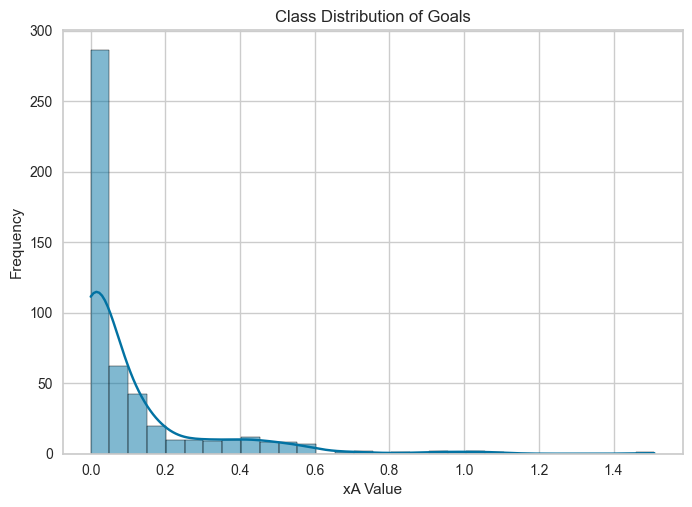

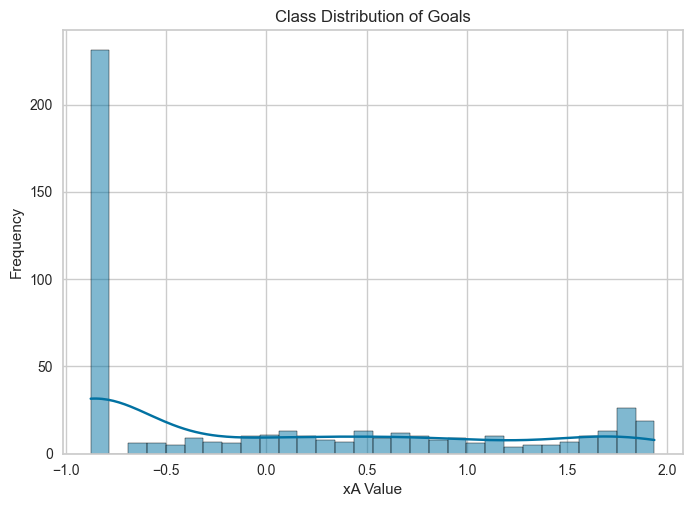

In [33]:

fwd_xa_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'FWD')]
fwd_xa_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '4')]

fwd_xa_data = fwd_xa_data[xa_features]
fwd_xa_data_tar = fwd_xa_data_tar[xa_features]

fwd_xa_data.reset_index(drop=True, inplace=True)
fwd_xa_data.reset_index(drop=True, inplace=True)

fwd_xa_data.drop(columns=['position'], inplace=True)
fwd_xa_data_tar.drop(columns=['xA', 'position'], inplace=True)



print(fwd_xa_data['xA'].value_counts())

sns.histplot(data=fwd_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=fwd_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

pt_fwd_xa = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_fwd_xa.fit(fwd_xa_data[['xA']])
joblib.dump(pt_fwd_xa, './models/pt_fwd_xa.pkl')  # Save fitted transformer

fwd_xa_data['xA'] = pt_fwd_xa.transform(fwd_xa_data[['xA']])


sns.histplot(data=fwd_xa_data, x='xA', bins=30, kde=True) #countplot(x='xA', data=fwd_xa_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xA Value')
plt.ylabel('Frequency')
plt.show()

### Base model


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005940 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2576
[LightGBM] [Info] Number of data points in the train set: 396, number of used features: 63
[LightGBM] [Info] Start training from score -0.017701
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

,Description,Value
0,Session id,4257
1,Target,xA
2,Target type,Regression
3,Original data shape,"(495, 76)"
4,Transformed data shape,"(495, 16)"
5,Transformed train set shape,"(396, 16)"
6,Transformed test set shape,"(99, 16)"
7,Numeric features,74
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3087,0.2621,0.5067,0.7276,0.2378,1.1198,0.6520
et,Extra Trees Regressor,0.3111,0.2655,0.5092,0.7245,0.2389,1.0102,0.6320
xgboost,Extreme Gradient Boosting,0.3375,0.3268,0.5678,0.6578,0.2623,1.2033,0.5370
gbr,Gradient Boosting Regressor,0.3445,0.2853,0.5276,0.7024,0.2526,1.1334,0.4790
ada,AdaBoost Regressor,0.3508,0.2813,0.5262,0.7053,0.2413,1.2116,0.4920
lightgbm,Light Gradient Boosting Machine,0.3525,0.2819,0.5260,0.7071,0.2524,1.1139,0.7230
dt,Decision Tree Regressor,0.3882,0.4448,0.6616,0.5276,0.3035,1.4251,0.3830
huber,Huber Regressor,0.4120,0.3720,0.6034,0.6162,0.2977,0.7188,0.4580
omp,Orthogonal Matching Pursuit,0.4318,0.3554,0.5906,0.6327,0.3113,0.7464,0.3940
ridge,Ridge Regression,0.4385,0.3671,0.6006,0.6206,0.3053,0.7588,0.3630


RandomForestRegressor(n_jobs=-1, random_state=4257)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


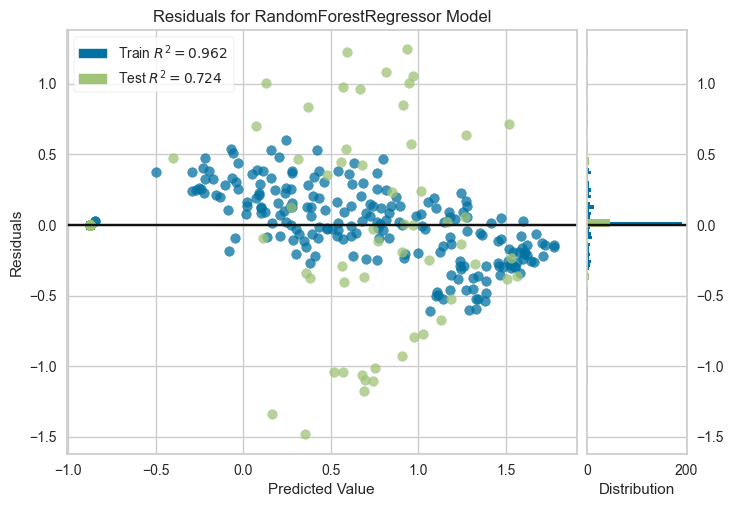

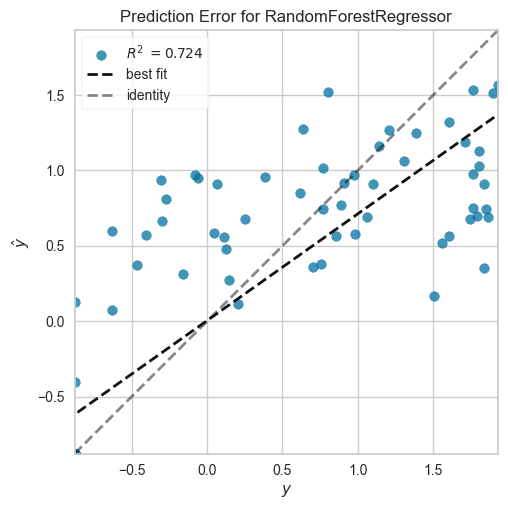

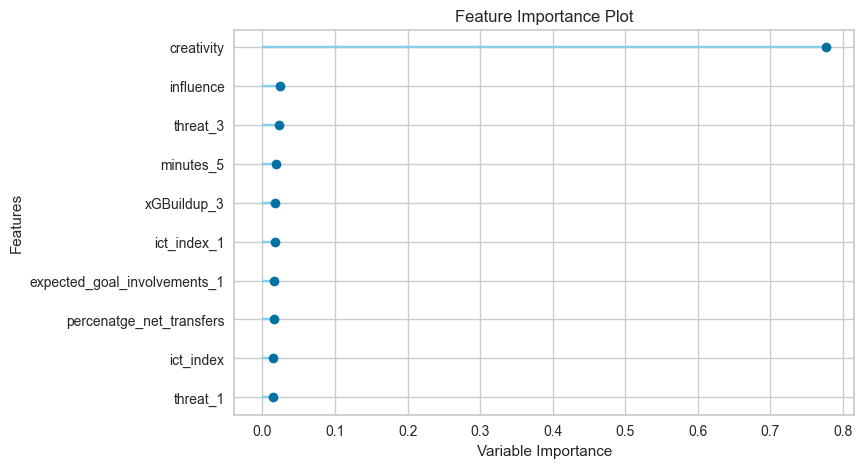

In [34]:
base_fwd_xa_model = setup(fwd_xa_data, target = 'xA',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_fwd_xa_best = base_fwd_xa_model.compare_models(sort='MAE', n_select=1)
print(base_fwd_xa_best)

print('Évaluate the model...')
evaluate_model(base_fwd_xa_best)

print('Plots...')
plot_model(base_fwd_xa_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_fwd_xa_best, plot='error')          # Prediction error plot
plot_model(base_fwd_xa_best, plot='feature')        # Feature importance

### Tune model


In [35]:
fwd_xa_tuned = tune_model(base_fwd_xa_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3821,0.2946,0.5427,0.6543,0.2859,0.8761
1,0.4350,0.3711,0.6092,0.6095,0.3068,0.6107
2,0.3000,0.1927,0.4390,0.7474,0.2246,0.8070
3,0.3920,0.3294,0.5739,0.5924,0.2900,1.2254
4,0.5440,0.6196,0.7871,0.4957,0.3613,0.8519
5,0.4276,0.3787,0.6154,0.5892,0.2942,0.9945
6,0.4918,0.5052,0.7108,0.5173,0.3626,1.0390
7,0.4381,0.3873,0.6224,0.5922,0.3225,0.6705
8,0.6139,0.6454,0.8033,0.4146,0.4076,0.9264


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [36]:
fwd_xa_final_model = finalize_model(base_fwd_xa_best)
save_model(fwd_xa_final_model, './models/fwd_xa_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat', 'starts',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'ict_index_1', 'influence_1',
                                              'creativity_1', 'threat_1',
                                              'minutes_1...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',


# Saves


## GK


saves
2     99
3     90
4     74
1     62
5     37
6     24
0     21
7     12
8     11
9      7
10     4
12     1
Name: count, dtype: int64


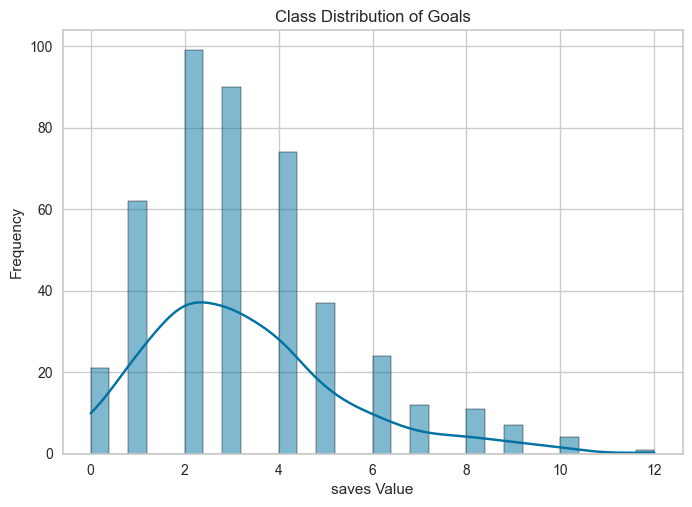

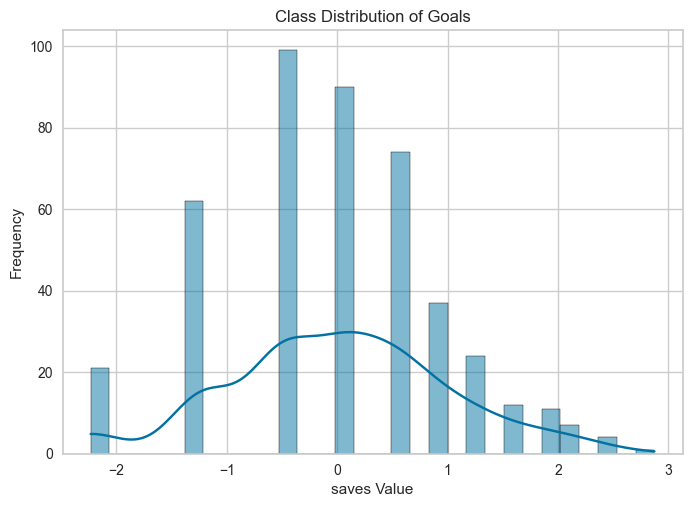

In [37]:
saves_features = ['position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',
            'saves',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]



g_saves_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_saves_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_saves_data = g_saves_data[saves_features]
g_saves_data_tar = g_saves_data_tar[saves_features]

g_saves_data.reset_index(drop=True, inplace=True)
g_saves_data.reset_index(drop=True, inplace=True)

g_saves_data.drop(columns=['position'], inplace=True)
g_saves_data_tar.drop(columns=['position', 'saves'], inplace=True)

print(g_saves_data['saves'].value_counts())

sns.histplot(data=g_saves_data, x='saves', bins=30, kde=True) #countplot(x='saves', data=g_saves_data)
plt.title('Class Distribution of Goals')
plt.xlabel('saves Value')
plt.ylabel('Frequency')
plt.show()

pt_gk_saves = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_gk_saves.fit(g_saves_data[['saves']])
joblib.dump(pt_gk_saves, './models/pt_gk_saves.pkl')  # Save fitted transformer

g_saves_data['saves'] = pt_gk_saves.transform(g_saves_data[['saves']])


sns.histplot(data=g_saves_data, x='saves', bins=30, kde=True) #countplot(x='saves', data=g_saves_data)
plt.title('Class Distribution of Goals')
plt.xlabel('saves Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001125 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1563
[LightGBM] [Info] Number of data points in the train set: 353, number of used features: 44
[LightGBM] [Info] Start training from score -0.034676
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

,Description,Value
0,Session id,8882
1,Target,saves
2,Target type,Regression
3,Original data shape,"(442, 75)"
4,Transformed data shape,"(442, 15)"
5,Transformed train set shape,"(353, 15)"
6,Transformed test set shape,"(89, 15)"
7,Numeric features,73
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.2572,0.1220,0.3461,0.8504,0.1873,1.2761,0.4280
gbr,Gradient Boosting Regressor,0.2614,0.1232,0.3473,0.8539,0.1829,1.1773,0.2970
et,Extra Trees Regressor,0.2657,0.1211,0.3467,0.8520,0.1896,1.3222,0.4100
xgboost,Extreme Gradient Boosting,0.2735,0.1329,0.3616,0.8394,0.1938,1.4127,0.3870
lightgbm,Light Gradient Boosting Machine,0.2764,0.1331,0.3637,0.8433,0.1898,1.2343,0.7580
ada,AdaBoost Regressor,0.2819,0.1282,0.3558,0.8458,0.1962,1.0480,0.3600
br,Bayesian Ridge,0.2985,0.1583,0.3956,0.8204,0.1890,1.2616,0.3030
en,Elastic Net,0.2989,0.1573,0.3943,0.8236,0.1908,1.2462,0.2730
llar,Lasso Least Angle Regression,0.3022,0.1607,0.3982,0.8213,0.1944,1.2173,0.2230
lasso,Lasso Regression,0.3022,0.1607,0.3982,0.8213,0.1944,1.2173,0.3260


RandomForestRegressor(n_jobs=-1, random_state=8882)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


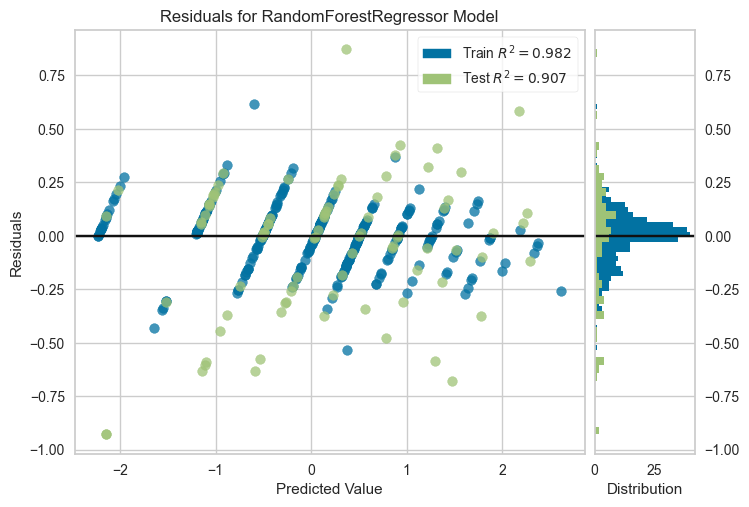

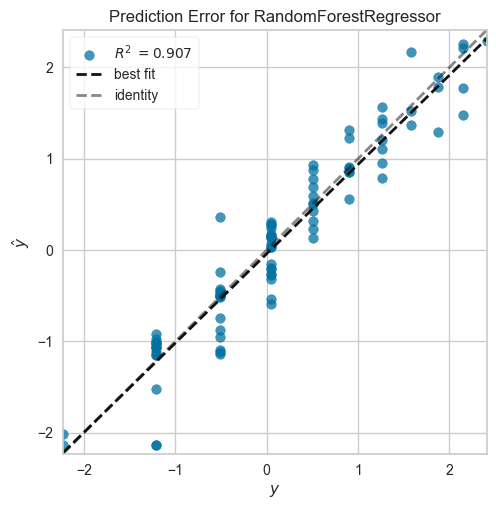

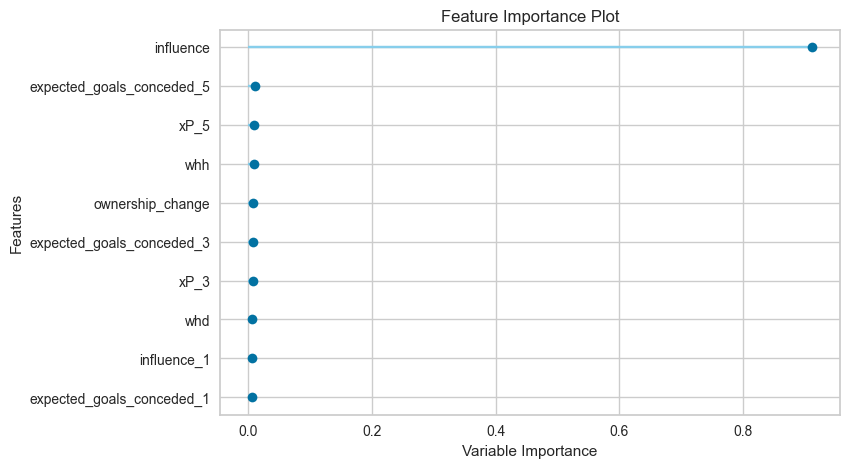

In [38]:
base_g_saves_model = setup(g_saves_data, target = 'saves',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_g_saves_best = base_g_saves_model.compare_models(sort='MAE', n_select=1)
print(base_g_saves_best)

print('Évaluate the model...')
evaluate_model(base_g_saves_best)

print('Plots...')
plot_model(base_g_saves_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_g_saves_best, plot='error')          # Prediction error plot
plot_model(base_g_saves_best, plot='feature')        # Feature importance

### Tune Model


In [39]:
g_saves_tuned = tune_model(base_g_saves_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.2362,0.1359,0.3687,0.6777,0.2191,2.2904
1,0.1320,0.0654,0.2557,0.9383,0.1683,0.4835
2,0.1989,0.1227,0.3502,0.8889,0.1864,0.8261
3,0.1882,0.1300,0.3606,0.7702,0.1885,2.0801
4,0.1842,0.1106,0.3326,0.9178,0.1840,0.8436
5,0.3204,0.2082,0.4563,0.7926,0.2567,1.6233
6,0.1821,0.1594,0.3993,0.8550,0.1721,0.5950
7,0.2538,0.1747,0.4179,0.8079,0.2315,1.5740
8,0.1802,0.1018,0.3191,0.8843,0.1837,0.9237


Fitting 10 folds for each of 10 candidates, totalling 100 fits


### Save Model


In [40]:
g_saves_final_model = finalize_model(base_g_saves_best)
save_model(g_saves_final_model, './models/g_saves_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
 

# Goals Conceded


In [41]:
xgc_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty',  'ownership_change', 'percenatge_net_transfers',
            'expected_goals_conceded',  'ict_index', 'influence', 'creativity', 'threat', 'selected', 'transfers_balance', 'transfers_in', 'transfers_out', 'value',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_3',  'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]

In [42]:
cols = [
 'clean_sheets_1',
 'expected_assists_1',
 'expected_goal_involvements_1',
 'expected_goals_1',
 'expected_goals_conceded_1',
 'goals_conceded_1',
 'goals_scored_1',
 'ict_index_1',
 'influence_1',
 'creativity_1',
 'threat_1',
 'minutes_1',
 'own_goals_1',
 'penalties_missed_1',
 'penalties_saved_1',
 'red_cards_1',
 'yellow_cards_1',
 'saves_1',
 'starts_1',
 'team_a_score_1',
 'team_h_score_1',
 'total_points_1',
 'goals_1',
 'shots_1',
 'xG_1',
 'xA_1',
 'assists_x_1',
 'assists_y_1',
 'key_passes_1',
 'npg_1',
 'npxG_1',
 'xGChain_1',
 'xGBuildup_1',
 'xP_1',
 'clean_sheets_3',
 'expected_assists_3',
 'expected_goal_involvements_3',
 'expected_goals_3',
 'expected_goals_conceded_3',
 'goals_conceded_3',
 'goals_scored_3',
 'ict_index_3',
 'influence_3',
 'creativity_3',
 'threat_3',
 'minutes_3',
 'own_goals_3',
 'penalties_missed_3',
 'penalties_saved_3',
 'red_cards_3',
 'yellow_cards_3',
 'saves_3',
 'starts_3',
 'team_a_score_3',
 'team_h_score_3',
 'total_points_3',
 'goals_3',
 'shots_3',
 'xG_3',
 'xA_3',
 'assists_x_3',
 'assists_y_3',
 'key_passes_3',
 'npg_3',
 'npxG_3',
 'xGChain_3',
 'xGBuildup_3',
 'xP_3',
 'clean_sheets_5',
 'expected_assists_5',
 'expected_goal_involvements_5',
 'expected_goals_5',
 'expected_goals_conceded_5',
 'goals_conceded_5',
 'goals_scored_5',
 'ict_index_5',
 'influence_5',
 'creativity_5',
 'threat_5',
 'minutes_5',
 'own_goals_5',
 'penalties_missed_5',
 'penalties_saved_5',
 'red_cards_5',
 'yellow_cards_5',
 'saves_5',
 'starts_5',
 'team_a_score_5',
 'team_h_score_5',
 'total_points_5',
 'goals_5',
 'shots_5',
 'xG_5',
 'xA_5',
 'assists_x_5',
 'assists_y_5',
 'key_passes_5',
 'npg_5',
 'npxG_5',
 'xGChain_5',
 'xGBuildup_5',
 'xP_5',
 'ownership_change',
 'percenatge_net_transfers',
 'pts_bps',
 'whh',
 'whd',
 'wha']

## GK


expected_goals_conceded
1.48    6
1.36    6
1.69    6
0.83    5
0.71    5
       ..
1.64    1
0.37    1
2.40    1
2.19    1
3.37    1
Name: count, Length: 234, dtype: int64


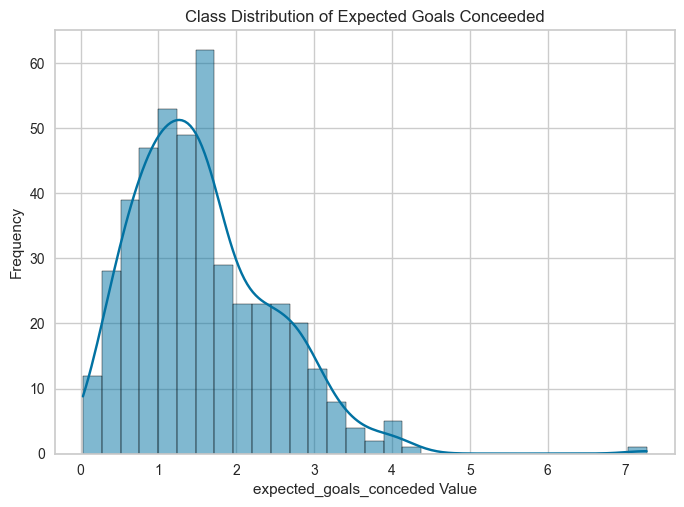

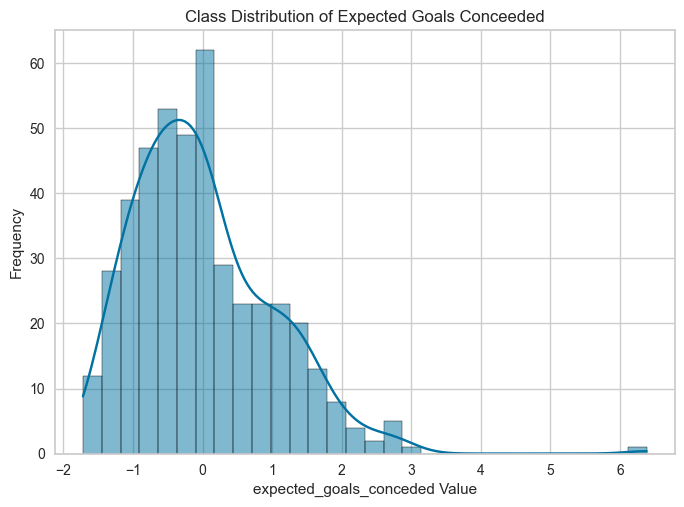

In [43]:
g_xgc_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_xgc_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_xgc_data = g_xgc_data[xgc_features]
g_xgc_data_tar = g_xgc_data_tar[xgc_features]

g_xgc_data.reset_index(drop=True, inplace=True)
g_xgc_data.reset_index(drop=True, inplace=True)

g_xgc_data.drop(columns=['position'], inplace=True)
g_xgc_data_tar.drop(columns=['position', 'expected_goals_conceded'], inplace=True)

print(g_xgc_data['expected_goals_conceded'].value_counts())

sns.histplot(data=g_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=g_xgc_data)
plt.title('Class Distribution of Expected Goals Conceeded')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()


scaler = StandardScaler()
g_xgc_data_scaled = pd.DataFrame(scaler.fit_transform(g_xgc_data), columns=g_xgc_data.columns)
joblib.dump(scaler, './models/scaler_gk_xgc.pkl')  # Save fitted scaler




# pt_gk_xgc = PowerTransformer(method='yeo-johnson',  standardize=True)
# pt_gk_xgc.fit(g_xgc_data[['expected_goals_conceded']])

# joblib.dump(pt_gk_xgc, './models/pt_gk_xgc.pkl')  # Save fitted transformer

# g_xgc_data['expected_goals_conceded'] = pt_gk_xgc.transform(g_xgc_data[['expected_goals_conceded']])




sns.histplot(data=g_xgc_data_scaled, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=g_xgc_data)
plt.title('Class Distribution of Expected Goals Conceeded')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()

In [44]:
data_cols_all = ['position', 'expected_goals_conceded',  'creativity', 'ict_index',  'influence',  'selected',  'threat',  'transfers_balance', 'transfers_in',  'transfers_out',  'value',
                 'team_h_difficulty',  'team_a_difficulty', 'ownership_change',  'percenatge_net_transfers', 'whh',  'whd',  'wha', 'xP',

            'clean_sheets_1',  'expected_assists_1',  'expected_goal_involvements_1',
            'expected_goals_1',  'expected_goals_conceded_1',  'goals_conceded_1',  'goals_scored_1',  'ict_index_1',  'influence_1',
            'creativity_1',  'threat_1',  'minutes_1',  'own_goals_1',  'penalties_missed_1',  'penalties_saved_1',  'red_cards_1',
            'yellow_cards_1',  'saves_1',  'starts_1',  'team_a_score_1',  'team_h_score_1',  'total_points_1',  'goals_1',  'shots_1',
            'xG_1',  'xA_1',  'assists_x_1',  'key_passes_1',  'npg_1',  'npxG_1',  'xGChain_1',  'xGBuildup_1',  'xP_1',

            'clean_sheets_3',  'expected_assists_3',  'expected_goal_involvements_3',  'expected_goals_3',  'expected_goals_conceded_3',
            'goals_conceded_3',  'goals_scored_3',  'ict_index_3',  'influence_3',  'creativity_3',  'threat_3',  'minutes_3',  'own_goals_3',
            'penalties_missed_3',  'penalties_saved_3',  'red_cards_3',  'yellow_cards_3',  'saves_3',  'starts_3',  'team_a_score_3',
            'team_h_score_3',  'total_points_3',  'goals_3',  'shots_3',  'xG_3',  'xA_3',  'assists_x_3', 'key_passes_3',
            'npg_3',  'npxG_3',  'xGChain_3',  'xGBuildup_3',  'xP_3',

            'clean_sheets_5',  'expected_assists_5',  'expected_goal_involvements_5',  'expected_goals_5',  'expected_goals_conceded_5',  'goals_conceded_5',
            'goals_scored_5',  'ict_index_5',  'influence_5',  'creativity_5',  'threat_5',  'minutes_5',  'own_goals_5',  'penalties_missed_5',  'penalties_saved_5',
            'red_cards_5',  'yellow_cards_5',  'saves_5',  'starts_5',  'team_a_score_5',  'team_h_score_5',  'total_points_5',  'goals_5',  'shots_5',  'xG_5',  'xA_5',
            'assists_x_5', 'key_passes_5',  'npg_5',  'npxG_5',  'xGChain_5',  'xGBuildup_5',  'xP_5',
        ]

In [45]:
g_xgc_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_xgc_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

# g_xgc_data = g_xgc_data[data_cols_all]

# g_xgc_data.reset_index(drop=True, inplace=True)
# g_xgc_data.reset_index(drop=True, inplace=True)

# g_xgc_data.drop(columns=['position'], inplace=True)
# # g_xgc_data_tar.drop(columns=['position', 'expected_goals_conceded'], inplace=True)

# print(g_xgc_data['expected_goals_conceded'].value_counts())

# sns.histplot(data=g_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=g_xgc_data)
# plt.title('Class Distribution of Expected Goals Conceeded')
# plt.xlabel('expected_goals_conceded Value')
# plt.ylabel('Frequency')
# plt.show()


# scaler = StandardScaler()
# g_xgc_data_scaled = pd.DataFrame(scaler.fit_transform(g_xgc_data), columns=g_xgc_data.columns)
# joblib.dump(scaler, './models/scaler_gk_xgc.pkl')  # Save fitted scaler

g_xgc_data

,Unnamed: 0,assists_x,bonus,bps,clean_sheets,creativity,element,expected_assists,expected_goal_involvements,expected_goals,...,npxG_5,xGChain_5,xGBuildup_5,xP_5,ownership_change,percenatge_net_transfers,pts_bps,whh,whd,wha
31,31,0,0,22,1,0.0,17,0.0,0.0,0.0,...,0.0,0.04,0.04,2.90,-788431.0,-0.184802,6.0,0.210,0.251,0.539
32,32,0,0,13,0,0.0,17,0.0,0.0,0.0,...,0.0,0.13,0.13,3.40,-169940.0,0.296254,3.0,0.778,0.136,0.086
461,461,0,0,29,0,0.0,524,0.0,0.0,0.0,...,0.0,0.07,0.07,3.80,189723.0,0.529864,4.0,0.135,0.211,0.654
462,462,0,0,17,0,0.0,524,0.0,0.0,0.0,...,0.0,0.07,0.07,4.34,145273.0,0.660914,2.0,0.676,0.189,0.135
463,463,0,0,23,1,0.0,524,0.0,0.0,0.0,...,0.0,0.09,0.09,4.68,182287.0,0.714268,6.0,0.654,0.211,0.135
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,11336,0,0,17,0,0.0,687,0.0,0.0,0.0,...,0.0,0.18,0.18,1.78,20014.0,0.451640,1.0,0.479,0.239,0.282
11285,11337,0,0,17,0,0.0,687,0.0,0.0,0.0,...,0.0,0.18,0.18,1.52,27053.0,0.716984,2.0,0.136,0.182,0.682
11286,11338,0,0,26,1,0.0,687,0.0,0.0,0.0,...,0.0,0.07,0.07,1.62,3890.0,0.129504,6.0,0.561,0.227,0.212
11287,11339,0,0,23,0,0.0,687,0.0,0.0,0.0,...,0.0,0.14,0.14,1.72,-50151.0,0.016213,2.0,0.654,0.188,0.157


In [46]:
data


,Unnamed: 0,assists_x,bonus,bps,clean_sheets,creativity,element,expected_assists,expected_goal_involvements,expected_goals,...,npxG_5,xGChain_5,xGBuildup_5,xP_5,ownership_change,percenatge_net_transfers,pts_bps,whh,whd,wha
0,0,0,0,0,0,0.0,127,0.00,0.00,0.0,...,NaN,NaN,NaN,NaN,0.0,-1.000000,0.0,0.441,0.271,0.288
1,1,0,0,0,0,0.0,127,0.00,0.00,0.0,...,0.0,0.00,0.00,0.00,-108.0,-1.000000,0.0,0.506,0.260,0.234
2,2,0,0,0,0,0.0,127,0.00,0.00,0.0,...,0.0,0.00,0.00,0.00,-314.0,-1.000000,0.0,0.565,0.236,0.199
3,3,0,0,0,0,0.0,127,0.00,0.00,0.0,...,0.0,0.05,0.04,0.00,-15.0,-1.000000,0.0,0.382,0.265,0.353
7,7,0,0,18,0,20.8,530,0.15,0.15,0.0,...,NaN,NaN,NaN,NaN,0.0,-0.234060,2.0,0.441,0.271,0.288
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,11336,0,0,17,0,0.0,687,0.00,0.00,0.0,...,0.0,0.18,0.18,1.78,20014.0,0.451640,1.0,0.479,0.239,0.282
11285,11337,0,0,17,0,0.0,687,0.00,0.00,0.0,...,0.0,0.18,0.18,1.52,27053.0,0.716984,2.0,0.136,0.182,0.682
11286,11338,0,0,26,1,0.0,687,0.00,0.00,0.0,...,0.0,0.07,0.07,1.62,3890.0,0.129504,6.0,0.561,0.227,0.212
11287,11339,0,0,23,0,0.0,687,0.00,0.00,0.0,...,0.0,0.14,0.14,1.72,-50151.0,0.016213,2.0,0.654,0.188,0.157


In [47]:
g_xgc_data[cols]

,clean_sheets_1,expected_assists_1,expected_goal_involvements_1,expected_goals_1,expected_goals_conceded_1,goals_conceded_1,goals_scored_1,ict_index_1,influence_1,creativity_1,...,npxG_5,xGChain_5,xGBuildup_5,xP_5,ownership_change,percenatge_net_transfers,pts_bps,whh,whd,wha
31,0.0,0.0,0.0,0.0,0.96,1.0,0.0,1.1,10.8,0.0,...,0.0,0.04,0.04,2.90,-788431.0,-0.184802,6.0,0.210,0.251,0.539
32,1.0,0.0,0.0,0.0,1.11,0.0,0.0,0.5,4.8,0.0,...,0.0,0.13,0.13,3.40,-169940.0,0.296254,3.0,0.778,0.136,0.086
461,0.0,0.0,0.0,0.0,1.43,1.0,0.0,0.2,2.0,0.0,...,0.0,0.07,0.07,3.80,189723.0,0.529864,4.0,0.135,0.211,0.654
462,0.0,0.0,0.0,0.0,3.63,3.0,0.0,7.6,76.0,0.0,...,0.0,0.07,0.07,4.34,145273.0,0.660914,2.0,0.676,0.189,0.135
463,0.0,0.0,0.0,0.0,3.06,3.0,0.0,2.9,29.0,0.0,...,0.0,0.09,0.09,4.68,182287.0,0.714268,6.0,0.654,0.211,0.135
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,0.0,0.0,0.0,0.0,1.58,2.0,0.0,2.2,22.4,0.0,...,0.0,0.18,0.18,1.78,20014.0,0.451640,1.0,0.479,0.239,0.282
11285,0.0,0.0,0.0,0.0,1.57,3.0,0.0,1.2,11.8,0.0,...,0.0,0.18,0.18,1.52,27053.0,0.716984,2.0,0.136,0.182,0.682
11286,0.0,0.0,0.0,0.0,1.36,2.0,0.0,2.5,24.8,0.0,...,0.0,0.07,0.07,1.62,3890.0,0.129504,6.0,0.561,0.227,0.212
11287,1.0,0.0,0.0,0.0,1.41,0.0,0.0,2.4,23.8,0.0,...,0.0,0.14,0.14,1.72,-50151.0,0.016213,2.0,0.654,0.188,0.157


In [48]:
cols = ['expected_goals_conceded',
 'ict_index',
 'saves',
 'selected',
 'team_a_score',
 'team_h_score',
 'transfers_balance',
 'transfers_in',
 'transfers_out',
 'value',
 'was_home',
 'yellow_cards',
 'team_h_difficulty',
 'team_a_difficulty',
 'position',
 'clean_sheets_1',
 'expected_assists_1',
 'expected_goal_involvements_1',
 'expected_goals_1',
 'expected_goals_conceded_1',
 'goals_conceded_1',
 'goals_scored_1',
 'ict_index_1',
 'influence_1',
 'creativity_1',
 'threat_1',
 'minutes_1',
 'own_goals_1',
 'penalties_missed_1',
 'penalties_saved_1',
 'red_cards_1',
 'yellow_cards_1',
 'saves_1',
 'starts_1',
 'team_a_score_1',
 'team_h_score_1',
 'total_points_1',
 'goals_1',
 'shots_1',
 'xG_1',
 'xA_1',
 'assists_x_1',
 'assists_y_1',
 'key_passes_1',
 'npg_1',
 'npxG_1',
 'xGChain_1',
 'xGBuildup_1',
 'xP_1',
 'clean_sheets_3',
 'expected_assists_3',
 'expected_goal_involvements_3',
 'expected_goals_3',
 'expected_goals_conceded_3',
 'goals_conceded_3',
 'goals_scored_3',
 'ict_index_3',
 'influence_3',
 'creativity_3',
 'threat_3',
 'minutes_3',
 'own_goals_3',
 'penalties_missed_3',
 'penalties_saved_3',
 'red_cards_3',
 'yellow_cards_3',
 'saves_3',
 'starts_3',
 'team_a_score_3',
 'team_h_score_3',
 'total_points_3',
 'goals_3',
 'shots_3',
 'xG_3',
 'xA_3',
 'assists_x_3',
 'assists_y_3',
 'key_passes_3',
 'npg_3',
 'npxG_3',
 'xGChain_3',
 'xGBuildup_3',
 'xP_3',
 'clean_sheets_5',
 'expected_assists_5',
 'expected_goal_involvements_5',
 'expected_goals_5',
 'expected_goals_conceded_5',
 'goals_conceded_5',
 'goals_scored_5',
 'ict_index_5',
 'influence_5',
 'creativity_5',
 'threat_5',
 'minutes_5',
 'own_goals_5',
 'penalties_missed_5',
 'penalties_saved_5',
 'red_cards_5',
 'yellow_cards_5',
 'saves_5',
 'starts_5',
 'team_a_score_5',
 'team_h_score_5',
 'total_points_5',
 'goals_5',
 'shots_5',
 'xG_5',
 'xA_5',
 'assists_x_5',
 'assists_y_5',
 'key_passes_5',
 'npg_5',
 'npxG_5',
 'xGChain_5',
 'xGBuildup_5',
 'xP_5',
 'ownership_change',
 'percenatge_net_transfers',
 'pts_bps',
 'whh',
 'whd',
 'wha']

In [49]:
preprocessed_g_xgc_data = preprocessed_g_xgc_data[['PC1',
 'PC2',
 'PC3',
 'PC4',
 'PC5',
 'PC6',
 'PC7',
 'PC8',
 'PC9',
 'PC10',
 'PC11',
 'PC12',
 'PC13',
 'PC14',
 'PC15',
 'PC16',
 'PC17',
 'PC18',
 'PC19',
 'PC20',
 'PC21',
 'PC22',
 'PC23',
 'PC24',
 'PC25',
 'PC26',
 'PC27',
 'PC28',
 'PC29',
 'PC30',
 'PC31',
 'PC32',
 'PC33',
 'PC34',
 'PC35',
 'PC36',
 'PC37',
 'PC38',
 'PC39',
 'PC40',
 'PC41',
 'PC42',
 'PC43',
 'PC44',
 'PC45',
 'PC46',
 'PC47',
 'PC48',
 'PC49',
 'PC50',
 'PC51',
 'PC52',
 'PC53',
 'expected_goals_conceded']]

NameError: name 'preprocessed_g_xgc_data' is not defined

In [ ]:
exp_xgc = setup(
        data=preprocessed_g_xgc_data,    # Use the NEW preprocessed DataFrame
        target="expected_goals_conceded", # Same target
        train_size=0.8,

        # These steps can now run on the PCA components:
        feature_selection=True,
        n_features_to_select=0.8,

        # --- Experiment Settings ---
        session_id=42
    )


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000357 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5174
[LightGBM] [Info] Number of data points in the train set: 290, number of used features: 53
[LightGBM] [Info] Start training from score 1.656241
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

,Description,Value
0,Session id,42
1,Target,expected_goals_conceded
2,Target type,Regression
3,Original data shape,"(363, 54)"
4,Transformed data shape,"(363, 43)"
5,Transformed train set shape,"(290, 43)"
6,Transformed test set shape,"(73, 43)"
7,Numeric features,53
8,Preprocess,True
9,Imputation type,simple


In [ ]:
g_xgc_data.columns.tolist()

['whh',
 'whd',
 'wha',
 'was_home',
 'team_h_difficulty',
 'team_a_difficulty',
 'ownership_change',
 'percenatge_net_transfers',
 'expected_goals_conceded',
 'ict_index',
 'influence',
 'creativity',
 'threat',
 'clean_sheets_1',
 'expected_goals_conceded_1',
 'goals_conceded_1',
 'ict_index_1',
 'influence_1',
 'creativity_1',
 'threat_1',
 'minutes_1',
 'own_goals_1',
 'penalties_saved_1',
 'yellow_cards_1',
 'saves_1',
 'starts_1',
 'team_a_score_1',
 'team_h_score_1',
 'total_points_1',
 'xGChain_1',
 'xGBuildup_1',
 'xP_1',
 'clean_sheets_3',
 'expected_goals_conceded_3',
 'goals_conceded_3',
 'ict_index_3',
 'influence_3',
 'creativity_3',
 'threat_3',
 'minutes_3',
 'own_goals_3',
 'penalties_saved_3',
 'yellow_cards_3',
 'saves_3',
 'starts_3',
 'team_a_score_3',
 'team_h_score_3',
 'total_points_3',
 'xGChain_3',
 'xGBuildup_3',
 'xP_3',
 'clean_sheets_5',
 'expected_goals_conceded_5',
 'goals_conceded_5',
 'ict_index_5',
 'influence_5',
 'creativity_5',
 'threat_5',
 'minut

In [ ]:
import pandas as pd
from pycaret.regression import setup, compare_models, tune_model, plot_model, finalize_model, save_model, pull
import matplotlib
matplotlib.use('Agg') # Set non-interactive backend for saving plots

# --- Add sklearn imports for manual preprocessing ---
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.decomposition import PCA
# ---------------------------------------------------

# --- Assumed Data Loading ---
# We assume 'g_xgc_data' is a pandas DataFrame that has been loaded.
# For example:
# g_xgc_data = pd.read_csv('your_data_file.csv')
# -----------------------------

try:
    target = "expected_goals_conceded"

    if target not in g_xgc_data.columns:
        raise ValueError(f"Target column '{target}' not in DataFrame.")

    y_data = g_xgc_data[target]
    X_data = g_xgc_data.drop(columns=target)

    # We must only preprocess numeric features
    # Categorical features would need separate handling (e.g., OneHotEncoding)
    numeric_features = X_data.select_dtypes(include=np.number).columns

    if len(numeric_features) == 0:
        raise ValueError("No numeric features found to preprocess.")

    print(f"Original numeric features found: {len(numeric_features)}")

    # --- 1. Build the Manual Preprocessing Pipeline ---
    manual_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),

        # 'normalize=True', 'normalize_method='zscore''
        ('scaler', StandardScaler()),

        # 'transformation=True', 'transformation_method='yeo-johnson''
        ('transformer', PowerTransformer(method='yeo-johnson')),

        # 'pca=True', 'pca_method='linear', 'pca_components=0.95'
        ('pca', PCA(n_components=0.95))
    ])

    # --- 2. Fit and Transform the Feature Data (X) ---
    print("Fitting manual preprocessing pipeline (Imputer, Scaler, Transformer, PCA)...")
    # We only fit/transform the numeric part of X
    X_processed = manual_pipeline.fit_transform(X_data[numeric_features])

    # Get the number of PCA components
    n_components = X_processed.shape[1]
    pca_feature_names = [f'PC{i+1}' for i in range(n_components)]
    print(f"PCA resulted in {n_components} components.")

    # Convert processed array back to a DataFrame
    X_processed_df = pd.DataFrame(X_processed, columns=pca_feature_names, index=X_data.index)

    # --- 3. Recombine Processed Features with Target ---
    # And any non-numeric columns that were skipped
    # non_numeric_features = X_data.select_dtypes(exclude=np.number)

    preprocessed_g_xgc_data = pd.concat([X_processed_df, y_data], axis=1)

    print("Manual preprocessing complete.")
    print(f"New DataFrame shape: {preprocessed_g_xgc_data.shape}")

    # --- 4. Run PyCaret setup on the *preprocessed* data ---
    print("\nProceeding with PyCaret setup...")
    exp_xgc = setup(
        data=preprocessed_g_xgc_data,    # Use the NEW preprocessed DataFrame
        target="expected_goals_conceded", # Same target
        train_size=0.8,

        # --- Preprocessing Pipeline ---
        # TURN OFF steps that were done manually:
        normalize=False,
        transformation=False,
        pca=False,

        # These steps can now run on the PCA components:
        feature_selection=True,
        n_features_to_select=0.8,
        remove_multicollinearity=True,    # Note: PCA components are orthogonal,
                                            # so this step might be redundant now,
                                            # but we leave it as per the original request.
        multicollinearity_threshold=0.95,

        # --- Experiment Settings ---
        session_id=42,
        # silent=True,
        # html=False
    )

    print("\nPyCaret setup complete (on manually preprocessed data).")

    # (The rest of the script: compare_models, tune_model, etc.)

    # --- 1. Compare Models ---
    print("\n--- Comparing all models... ---")
    # This trains & evaluates all models, returning the best one (based on R2 by default)
    best_model = compare_models()
    print("\n--- Model Comparison Grid ---")
    print(pull()) # pull() fetches the comparison grid
    print(f"\n--- Best Model Found: {type(best_model).__name__} ---")
    print(best_model)

    # --- 2. Tune the Best Model ---
    print(f"\n--- Tuning {type(best_model).__name__}... ---")
    tuned_model = tune_model(best_model)
    print("\n--- Tuned Model Results ---")
    print(pull()) # pull() fetches the tuning results
    print(tuned_model)

    # --- 3. Plot Model ---
    print("\n--- Generating Model Plots ---")
    # Saves plots to the local directory
    plot_model(tuned_model, plot='residuals', save=True)
    print("Residuals plot saved as 'Residuals.png'")

    try:
        # Some models may not support feature importance
        plot_model(tuned_model, plot='feature', save=True)
        print("Feature Importance plot saved as 'Feature Importance.png'")
    except Exception as e:
        print(f"Could not generate Feature Importance plot: {e}")

    # --- 4. Finalize Model ---
    print("\n--- Finalizing Model (training on full dataset)... ---")
    final_model = finalize_model(tuned_model)
    print("--- Final Model ---")
    print(final_model)

    # --- 5. Save Model ---
    save_path = 'final_xgc_pipeline'
    save_model(final_model, save_path)
    print(f"\n--- Model pipeline saved successfully as '{save_path}.pkl' ---")

except Exception as e:
    print(f"\nAn error occurred during the PyCaret modeling workflow: {e}")


Original numeric features found: 68
Fitting manual preprocessing pipeline (Imputer, Scaler, Transformer, PCA)...
PCA resulted in 34 components.
Manual preprocessing complete.
New DataFrame shape: (363, 35)

Proceeding with PyCaret setup...


,Description,Value
0,Session id,42
1,Target,expected_goals_conceded
2,Target type,Regression
3,Original data shape,"(363, 35)"
4,Transformed data shape,"(363, 28)"
5,Transformed train set shape,"(290, 28)"
6,Transformed test set shape,"(73, 28)"
7,Numeric features,34
8,Preprocess,True
9,Imputation type,simple



PyCaret setup complete (on manually preprocessed data).

--- Comparing all models... ---


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
br,Bayesian Ridge,0.6654,0.7068,0.8314,0.1139,0.3128,0.6547,0.1170
omp,Orthogonal Matching Pursuit,0.6978,0.7879,0.8741,0.0592,0.3228,0.6900,0.1750
ada,AdaBoost Regressor,0.6986,0.7794,0.8718,0.0580,0.3251,0.7312,0.2250
ridge,Ridge Regression,0.6789,0.7371,0.8502,0.0476,0.3223,0.6500,0.1530
lr,Linear Regression,0.6794,0.7381,0.8508,0.0460,0.3226,0.6501,1.7680
lar,Least Angle Regression,0.6794,0.7381,0.8508,0.0460,0.3226,0.6501,0.1150
huber,Huber Regressor,0.6821,0.7684,0.8706,0.0090,0.3260,0.6308,0.1260
et,Extra Trees Regressor,0.7135,0.8198,0.8976,-0.0164,0.3327,0.7333,0.3170
rf,Random Forest Regressor,0.7213,0.8338,0.9036,-0.0295,0.3340,0.7373,0.4540
gbr,Gradient Boosting Regressor,0.7384,0.8460,0.9097,-0.0455,0.3390,0.7339,0.3000



--- Model Comparison Grid ---
                                    Model     MAE     MSE    RMSE      R2  \
br                         Bayesian Ridge  0.6654  0.7068  0.8314  0.1139   
omp           Orthogonal Matching Pursuit  0.6978  0.7879  0.8741  0.0592   
ada                    AdaBoost Regressor  0.6986  0.7794  0.8718  0.0580   
ridge                    Ridge Regression  0.6789  0.7371  0.8502  0.0476   
lr                      Linear Regression  0.6794  0.7381  0.8508  0.0460   
lar                Least Angle Regression  0.6794  0.7381  0.8508  0.0460   
huber                     Huber Regressor  0.6821  0.7684  0.8706  0.0090   
et                  Extra Trees Regressor  0.7135  0.8198  0.8976 -0.0164   
rf                Random Forest Regressor  0.7213  0.8338  0.9036 -0.0295   
gbr           Gradient Boosting Regressor  0.7384  0.8460  0.9097 -0.0455   
lasso                    Lasso Regression  0.7392  0.8799  0.9242 -0.0458   
en                            Elastic Net  0.

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.6671,0.5991,0.7740,0.2476,0.3200,0.8363
1,0.6718,0.6912,0.8314,0.3105,0.3262,0.8621
2,0.7459,1.2243,1.1065,0.2248,0.3240,0.5686
3,0.6777,0.6722,0.8199,-0.5354,0.3342,0.5756
4,0.6352,0.6290,0.7931,0.3237,0.2837,0.4789
5,0.7305,0.8267,0.9092,0.1294,0.3282,0.5306
6,0.7377,0.7247,0.8513,-0.2595,0.3520,0.7790
7,0.7261,0.8354,0.9140,0.1952,0.3685,0.8743
8,0.5370,0.4325,0.6577,0.3911,0.2454,0.5997


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).

--- Tuned Model Results ---
         MAE     MSE    RMSE      R2   RMSLE    MAPE
Fold                                                
0     0.6671  0.5991  0.7740  0.2476  0.3200  0.8363
1     0.6718  0.6912  0.8314  0.3105  0.3262  0.8621
2     0.7459  1.2243  1.1065  0.2248  0.3240  0.5686
3     0.6777  0.6722  0.8199 -0.5354  0.3342  0.5756
4     0.6352  0.6290  0.7931  0.3237  0.2837  0.4789
5     0.7305  0.8267  0.9092  0.1294  0.3282  0.5306
6     0.7377  0.7247  0.8513 -0.2595  0.3520  0.7790
7     0.7261  0.8354  0.9140  0.1952  0.3685  0.8743
8     0.5370  0.4325  0.6577  0.3911  0.2454  0.5997
9     0.5276  0.4363  0.6605  0.0910  0.2507  0.4333
Mean  0.6657  0.7071  0.8318  0.1118  0.3133  0.6538
Std   0.0750  0.2160  0.1238  0.2753  0.0386  0.1587
BayesianRidge()



Residuals plot saved as 'Residuals.png'


Feature Importance plot saved as 'Feature Importance.png'

--- Finalizing Model (training on full dataset)... ---
--- Final Model ---
Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['PC1', 'PC2', 'PC3', 'PC4', 'PC5',
                                             'PC6', 'PC7', 'PC8', 'PC9', 'PC10',
                                             'PC11', 'PC12', 'PC13', 'PC14',
                                             'PC15', 'PC16', 'PC17', 'PC18',
                                             'PC19', 'PC20', 'PC21', 'PC22',
                                             'PC23', 'PC24', 'PC25', 'PC26',
                                             'PC27', 'PC28', 'PC29', 'PC30', ...],
                                    transformer=SimpleImputer())),
                ('categorical_imputer',
                 TransformerWrapper(include=[],
                                    transformer=SimpleImputer(strategy='most_frequ

In [ ]:
exp_xgc = setup(
    data=g_xgc_data,                 # The DataFrame to process
    target="expected_goals_conceded", # The column we want to predict
    train_size=0.8,                   # Use 80% of data for training

    # --- Preprocessing Pipeline ---
    # Scaling
    normalize=True,                   # Enable feature scaling
    normalize_method='zscore',        # Use StandardScaler (mean=0, std=1)

    # Transformation
    transformation=True,              # Enable power transformation
    transformation_method='yeo-johnson', # Use Yeo-Johnson to handle non-Gaussian data

    # Dimensionality Reduction
    pca=True,                         # Enable Principal Component Analysis
    pca_method='linear',              # Use standard linear PCA
    pca_components=0.95,              # Keep components that explain 95% of variance

    # Feature Selection
    feature_selection=True,           # Enable feature selection
    n_features_to_select=0.8,         # Keep the top 80% of most important features

    # Feature Engineering
    remove_multicollinearity=True,    # Automatically remove highly correlated features
    multicollinearity_threshold=0.95, # Correlation threshold (95%)

    # --- Experiment Settings ---
    session_id=42,                    # Set a random seed for reproducibility
)


ValueError: X does not contain the columns listed in cols

In [ ]:
from sklearn.preprocessing import StandardScaler
# import numpy as np


X = g_xgc_data.drop(columns=['expected_goals_conceded'])
y = g_xgc_data[['expected_goals_conceded']]

scaler = StandardScaler()
g_xgc_data_scaled = scaler.fit_transform(X)

y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y)

pca = PCA(n_components=0.95)  # Retain 95% of variance
g_xgc_data_pca = pca.fit_transform(g_xgc_data_scaled)
print(g_xgc_data_scaled.shape, g_xgc_data_pca.shape)

pca_xgc_g = pd.DataFrame(g_xgc_data_pca)
pca_xgc_g['expected_goals_conceded'] = y_scaled
pca_xgc_g
# explained_variance = pca.explained_variance_ratio_
# cumulative_variance = np.cumsum(explained_variance)

# print("Explained variance per component:")
# print(explained_variance)

# print("\nCumulative explained variance:")
# print(cumulative_variance)


(363, 116) (363, 40)


,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,expected_goals_conceded
0,-6.178045,0.682211,1.543990,-0.708990,0.467209,2.081259,0.625414,-0.321207,3.552993,0.608110,...,-1.013685,-1.158104,1.152072,4.068194,-0.129092,0.902384,-0.744453,0.895710,-0.814418,-0.588128
1,-5.336813,2.996906,0.531384,-1.242742,1.370839,-1.654814,2.185837,-0.628348,-2.708476,0.212976,...,-0.810031,-0.685738,-0.197369,0.932410,-0.364630,0.125337,-0.504567,-0.049111,0.073122,-0.742536
2,1.339954,1.722701,-3.365710,-0.807772,1.384783,4.687126,-0.702356,-1.161685,0.751054,-3.474688,...,-1.376991,0.053825,0.270004,-0.609436,1.605256,-1.222584,-0.551541,0.883506,-0.300314,2.191208
3,7.187958,-0.991512,-4.651276,-0.240652,-0.469457,0.809906,0.424011,-2.156070,-2.753062,-0.868472,...,-1.151754,-0.756696,0.645354,-0.410710,0.773765,-0.532937,-0.609609,1.764473,0.187245,1.562549
4,4.732348,-1.354392,-3.779462,-0.196700,-0.893454,0.414078,-0.171899,-0.092545,-1.890992,-4.397817,...,-0.389671,-0.818826,1.353755,-0.415966,-0.137781,-0.620204,-0.221713,2.345668,0.510830,-0.632245
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,-1.577697,-2.914905,0.456207,-0.215524,-1.137713,-0.625554,1.021416,0.857782,-0.552023,0.025482,...,-0.322670,-0.420763,-0.019472,0.049880,0.201256,0.393571,-0.367970,-0.230279,-0.026551,-1.591777
359,-6.321817,-3.484811,2.308992,-0.420630,1.941899,13.621906,-1.830044,-1.211112,-0.654446,-1.187278,...,-1.188437,-1.132095,-0.085723,-0.883447,1.281656,3.467249,1.486040,0.751678,-0.094848,0.691249
360,-2.279285,-5.168541,1.091457,0.233718,0.289782,5.325276,0.252491,-1.592200,-2.438105,0.865989,...,0.307677,-0.056373,-0.329816,-0.001932,-1.945301,-3.071264,-0.444925,-0.797945,-0.445407,0.261113
361,-2.363173,-4.228460,0.880787,-0.041290,0.385669,6.231100,0.282046,-1.091752,-0.896716,1.960192,...,0.433229,0.112281,0.225474,0.074423,-1.500891,-3.826008,-0.065103,-0.239830,-0.882590,1.419170


In [ ]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("Explained variance per component:")
print(explained_variance)

print("\nCumulative explained variance:")
print(cumulative_variance)

Explained variance per component:
[0.10961766 0.10732548 0.07450455 0.06804266 0.05437241 0.04208285
 0.04110856 0.03812905 0.03456111 0.03157757 0.02608365 0.0249178
 0.02382941 0.02328124 0.020346   0.01978847 0.01877029 0.01718929
 0.01542079 0.01386199 0.01305392 0.0123296  0.01074472 0.00992492
 0.00961957 0.009065   0.00862025 0.00808867 0.00758714 0.00731744
 0.00641435 0.00600513 0.00583173 0.00573032 0.00541332 0.00507773
 0.00501752 0.00437509 0.00409142 0.00400116]

Cumulative explained variance:
[0.10961766 0.21694314 0.29144769 0.35949035 0.41386277 0.45594562
 0.49705418 0.53518323 0.56974434 0.60132191 0.62740556 0.65232337
 0.67615278 0.69943401 0.71978002 0.73956849 0.75833878 0.77552807
 0.79094886 0.80481085 0.81786476 0.83019436 0.84093908 0.850864
 0.86048356 0.86954856 0.87816881 0.88625748 0.89384461 0.90116205
 0.9075764  0.91358152 0.91941326 0.92514358 0.9305569  0.93563462
 0.94065215 0.94502723 0.94911866 0.95311982]


In [ ]:
from pycaret.regression import *

base_g_xgc_model = setup(
    data=g_xgc_data,
    target='expected_goals_conceded',
    train_size=0.8,
    normalize=True,                    # Enables StandardScaler internally
    normalize_method='zscore',         # StandardScaler
    pca=True,                          # Turn on PCA
    pca_method='linear',               # Equivalent to sklearn PCA
    pca_components=0.95,               # Keep 95% variance
    remove_multicollinearity=True,
    multicollinearity_threshold=0.95,
    feature_selection=True
)


ValueError: X does not contain the columns listed in cols

In [ ]:
base_g_xgc_best = base_g_xgc_model.compare_models(sort='MAE', n_select=1)
print(base_g_xgc_best)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
huber,Huber Regressor,0.6539,0.6934,0.8207,0.0734,0.3123,0.6328,0.2650
ridge,Ridge Regression,0.6576,0.7018,0.8262,0.0534,0.3164,0.6550,0.2650
lr,Linear Regression,0.6578,0.7022,0.8265,0.0523,0.3167,0.6547,1.7570
lar,Least Angle Regression,0.6578,0.7022,0.8265,0.0523,0.3167,0.6547,0.2560
br,Bayesian Ridge,0.6580,0.7048,0.8258,0.0723,0.3130,0.6735,0.2590
ada,AdaBoost Regressor,0.6756,0.7375,0.8476,0.0340,0.3214,0.7221,0.6670
omp,Orthogonal Matching Pursuit,0.6990,0.8049,0.8809,-0.0232,0.3308,0.7434,0.2500
et,Extra Trees Regressor,0.6998,0.8074,0.8862,-0.0666,0.3319,0.7431,0.7100
lightgbm,Light Gradient Boosting Machine,0.7067,0.8416,0.8982,-0.0926,0.3372,0.7172,0.5250
rf,Random Forest Regressor,0.7117,0.8233,0.8947,-0.0898,0.3361,0.7508,0.9430


HuberRegressor()


### Base Model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000146 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3909
[LightGBM] [Info] Number of data points in the train set: 290, number of used features: 40
[LightGBM] [Info] Start training from score 0.033762
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

,Description,Value
0,Session id,8348
1,Target,expected_goals_conceded
2,Target type,Regression
3,Original data shape,"(363, 41)"
4,Transformed data shape,"(363, 9)"
5,Transformed train set shape,"(290, 9)"
6,Transformed test set shape,"(73, 9)"
7,Numeric features,40
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
knn,K Neighbors Regressor,0.7811,1.0262,0.9917,0.0133,0.4207,2.2196,0.2170
et,Extra Trees Regressor,0.7817,1.0038,0.9854,0.0183,0.4281,1.8975,0.2800
omp,Orthogonal Matching Pursuit,0.7942,1.0270,0.9946,0.0090,0.4788,1.6369,0.1100
rf,Random Forest Regressor,0.7971,1.0638,1.0141,-0.0513,0.4246,2.2412,0.3280
br,Bayesian Ridge,0.8013,1.0516,1.0024,-0.0054,0.4471,1.9487,0.2300
huber,Huber Regressor,0.8054,1.0789,1.0148,-0.0293,0.4456,1.9712,0.1330
ada,AdaBoost Regressor,0.8117,1.0395,1.0005,-0.0097,0.4461,2.0253,0.2180
ridge,Ridge Regression,0.8120,1.0814,1.0169,-0.0372,0.4416,2.0507,0.1160
lar,Least Angle Regression,0.8124,1.0824,1.0174,-0.0384,0.4415,2.0533,0.1090
lr,Linear Regression,0.8124,1.0824,1.0174,-0.0384,0.4415,2.0533,0.4010


KNeighborsRegressor(n_jobs=-1)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


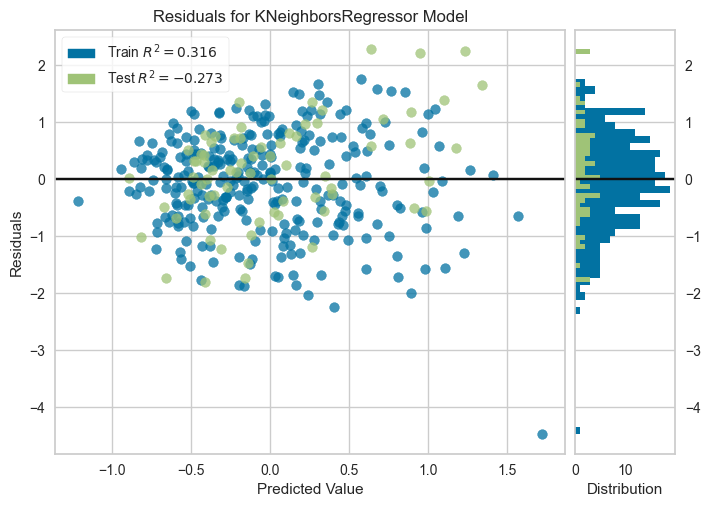

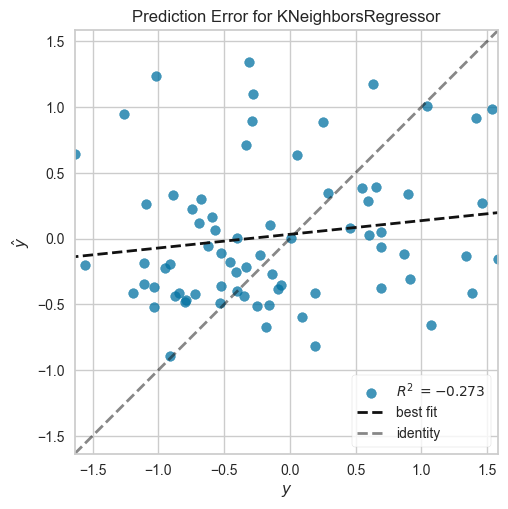

TypeError: Feature Importance and RFE plots not available for estimators that doesnt support coef_ or feature_importances_ attribute.

In [ ]:
base_g_xgc_model = setup(pca_xgc_g, target = 'expected_goals_conceded',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                 )

base_g_xgc_best = base_g_xgc_model.compare_models(sort='MAE', n_select=1)
print(base_g_xgc_best)

print('Évaluate the model...')
evaluate_model(base_g_xgc_best)

print('Plots...')
plot_model(base_g_xgc_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_g_xgc_best, plot='error')          # Prediction error plot
plot_model(base_g_xgc_best, plot='feature')        # Feature importance

### Tuned Model


In [ ]:
g_xgc_tuned = tune_model(base_g_xgc_best, optimize='MAE')

Fitting 10 folds for each of 10 candidates, totalling 100 fits


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

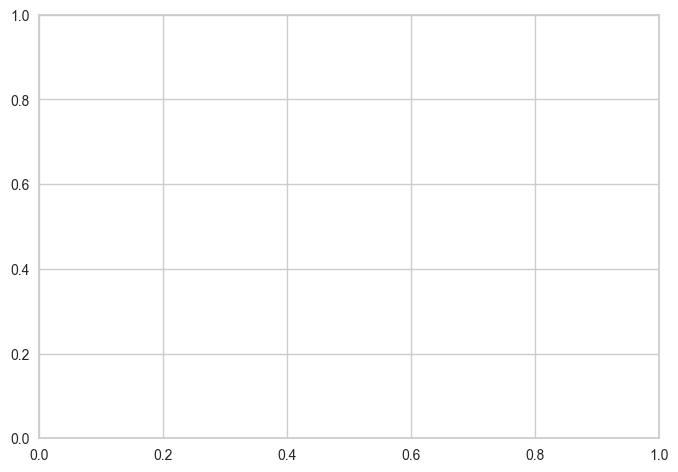

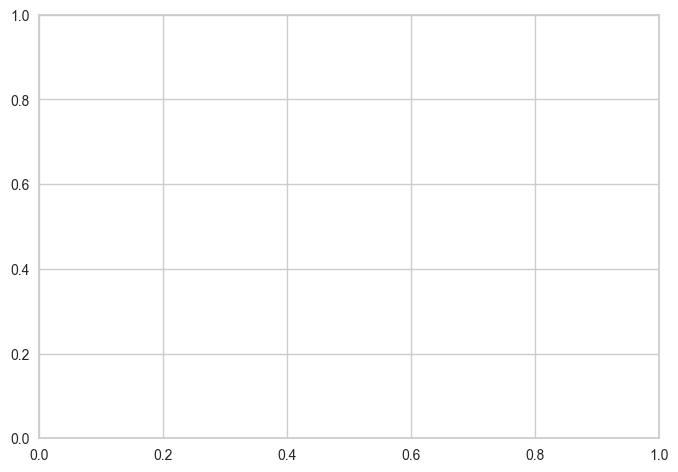

In [ ]:
evaluate_model(g_xgc_tuned)

### Save Model


In [ ]:
g_xgc_final_model = finalize_model(g_xgc_tuned)
save_model(g_xgc_final_model, './models/g_xgc_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1', 'ict_index_1',
                                              'influence_1', 'creativity_1'...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',
 

## Def


expected_goals_conceded
0.83    19
1.87    17
0.71    14
1.69    14
0.56    14
        ..
2.47     1
4.15     1
0.15     1
1.37     1
0.21     1
Name: count, Length: 297, dtype: int64


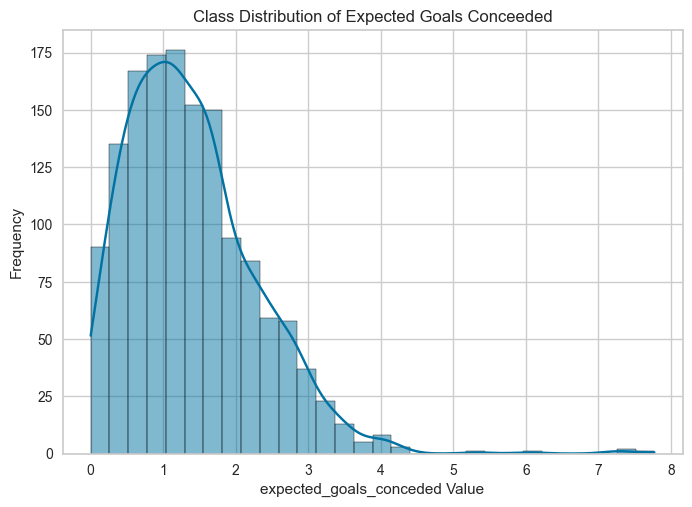

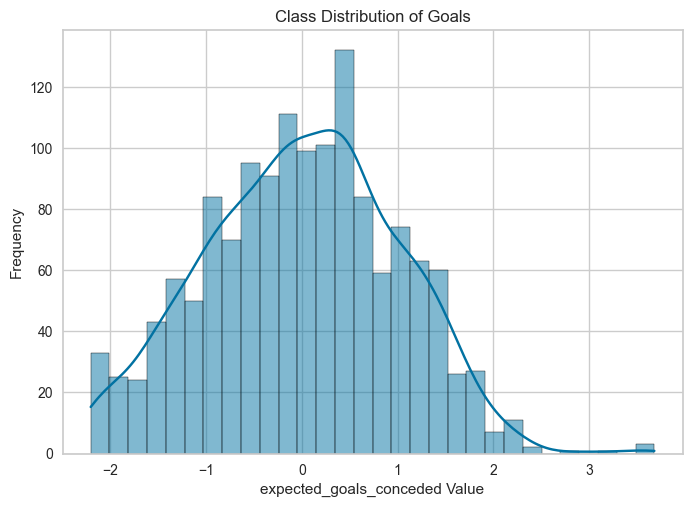

In [ ]:
def_xgc_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_xgc_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_xgc_data = def_xgc_data[xgc_features]
def_xgc_data_tar = def_xgc_data_tar[xgc_features]

def_xgc_data.reset_index(drop=True, inplace=True)
def_xgc_data.reset_index(drop=True, inplace=True)

def_xgc_data.drop(columns=['position'], inplace=True)
def_xgc_data_tar.drop(columns=['position', 'expected_goals_conceded'], inplace=True)

print(def_xgc_data['expected_goals_conceded'].value_counts())

sns.histplot(data=def_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=def_xgc_data)
plt.title('Class Distribution of Expected Goals Conceeded')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()

pt_def_xgc = PowerTransformer(method='yeo-johnson',  standardize=True)
pt_def_xgc.fit(def_xgc_data[['expected_goals_conceded']])
joblib.dump(pt_def_xgc, './models/pt_def_xgc.pkl')  # Save fitted transformer

def_xgc_data['expected_goals_conceded'] = pt_def_xgc.transform(def_xgc_data[['expected_goals_conceded']])


sns.histplot(data=def_xgc_data, x='expected_goals_conceded', bins=30, kde=True) #countplot(x='expected_goals_conceded', data=def_xgc_data)
plt.title('Class Distribution of Goals')
plt.xlabel('expected_goals_conceded Value')
plt.ylabel('Frequency')
plt.show()


### Base Model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001344 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5004
[LightGBM] [Info] Number of data points in the train set: 1146, number of used features: 57
[LightGBM] [Info] Start training from score -0.006998


,Description,Value
0,Session id,966
1,Target,expected_goals_conceded
2,Target type,Regression
3,Original data shape,"(1433, 70)"
4,Transformed data shape,"(1433, 14)"
5,Transformed train set shape,"(1146, 14)"
6,Transformed test set shape,"(287, 14)"
7,Numeric features,68
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.7240,0.8436,0.9162,0.1539,0.4020,2.2991,0.3550
rf,Random Forest Regressor,0.7244,0.8269,0.9072,0.1766,0.4368,1.5739,1.0970
et,Extra Trees Regressor,0.7246,0.8098,0.8979,0.1942,0.4342,1.7889,0.7910
xgboost,Extreme Gradient Boosting,0.7310,0.8450,0.9170,0.1528,0.4055,2.1254,0.3670
gbr,Gradient Boosting Regressor,0.7358,0.8434,0.9167,0.1604,0.4390,1.8435,0.4250
ridge,Ridge Regression,0.7788,0.9281,0.9623,0.0763,0.4741,1.6270,0.5140
lr,Linear Regression,0.7790,0.9289,0.9627,0.0757,0.4742,1.6248,0.5170
ada,AdaBoost Regressor,0.7797,0.9122,0.9540,0.0916,0.4890,1.7036,0.3160
br,Bayesian Ridge,0.7850,0.9326,0.9649,0.0711,0.4884,1.6179,0.7990
en,Elastic Net,0.8046,0.9626,0.9802,0.0421,0.5330,1.4824,0.7340


LGBMRegressor(n_jobs=-1, random_state=966)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


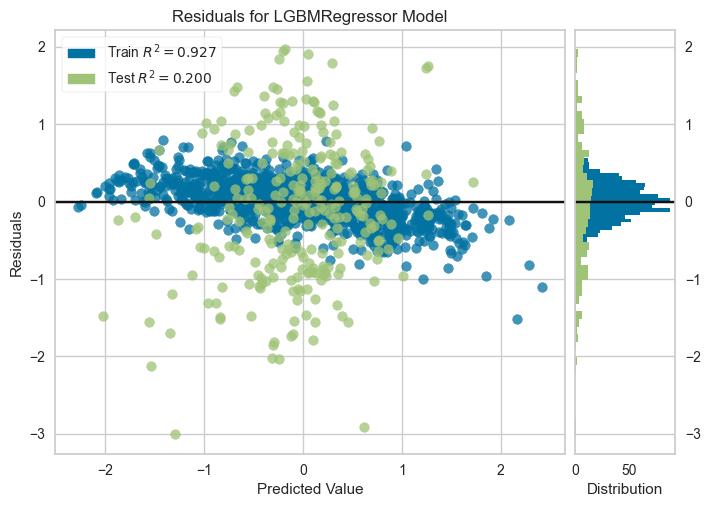

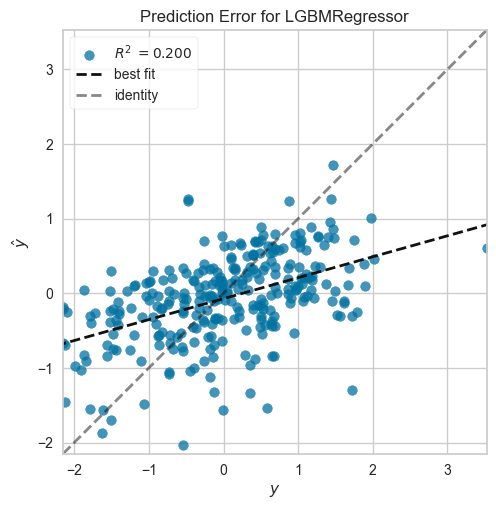

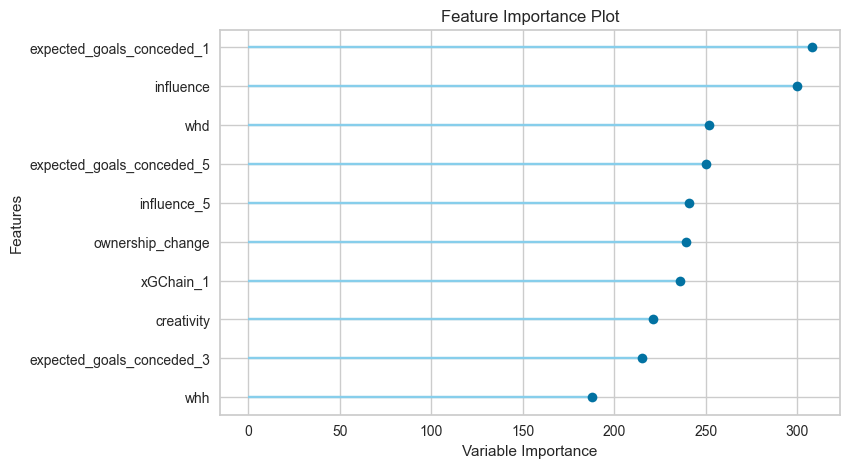

In [ ]:
base_def_xgc_model = setup(def_xgc_data, target = 'expected_goals_conceded',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_def_xgc_best = base_def_xgc_model.compare_models(sort='MAE', n_select=1)
print(base_def_xgc_best)

print('Évaluate the model...')
evaluate_model(base_def_xgc_best)

print('Plots...')
plot_model(base_def_xgc_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_def_xgc_best, plot='error')          # Prediction error plot
plot_model(base_def_xgc_best, plot='feature')        # Feature importance

### Tuned Model


In [ ]:
def_xgc_tuned = tune_model(base_def_xgc_best, optimize='MAE')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.7928,1.0234,1.0116,0.0625,0.4388,2.9528
1,0.7865,0.8880,0.9423,0.1429,0.4593,1.6771
2,0.7044,0.8512,0.9226,0.0311,0.3926,1.6673
3,0.6201,0.6233,0.7895,0.3469,0.3834,1.0826
4,0.7111,0.8728,0.9343,0.2033,0.4204,1.2544
5,0.7815,0.9222,0.9603,0.1892,0.4202,2.0064
6,0.6852,0.7261,0.8521,0.3552,0.4289,1.4244
7,0.7689,0.8567,0.9256,0.0469,0.3994,1.5407
8,0.7059,0.7812,0.8839,0.1600,0.3932,4.7483


Fitting 10 folds for each of 10 candidates, totalling 100 fits


### Save Model


In [ ]:
def_xgc_final_model = finalize_model(base_def_xgc_best)
save_model(def_xgc_final_model, './models/def_xgc_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1', 'ict_index_1',
                                              'influence_1', 'creativity_1'...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',
 

# XGC


In [82]:
xgc_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty',  'ownership_change', 'percenatge_net_transfers',
            'expected_goals_conceded',  'ict_index', 'influence', 'creativity', 'threat', 'selected', 'transfers_balance', 'transfers_in', 'transfers_out', 'value',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_3',  'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]

In [83]:
cols = [
 'creativity',
 'expected_goals_conceded',
 'ict_index',
 'influence',
 'selected',
 'threat',
 'transfers_balance',
 'transfers_in',
 'transfers_out',
 'value',
 'was_home',
 'team_h_difficulty',
 'team_a_difficulty',
#  'position',

 'clean_sheets_1',
 'expected_goals_conceded_1',
 'goals_conceded_1',
 'ict_index_1',
 'influence_1',
 'creativity_1',
 'threat_1',
 'minutes_1',
 'penalties_missed_1',
 'penalties_saved_1',
 'red_cards_1',
 'yellow_cards_1',
 'saves_1',
 'starts_1',
 'team_a_score_1',
 'team_h_score_1',
 'total_points_1',
  'xP_1',

 'clean_sheets_3',
 'expected_goals_conceded_3',
 'goals_conceded_3',
 'ict_index_3',
 'influence_3',
 'creativity_3',
 'threat_3',
 'minutes_3',
 'yellow_cards_3',
 'saves_3',
 'starts_3',
 'team_a_score_3',
 'team_h_score_3',
 'total_points_3',
  'xP_3',

 'clean_sheets_5',
 'expected_goals_conceded_5',
 'goals_conceded_5',
 'ict_index_5',
 'influence_5',
 'creativity_5',
 'threat_5',
 'minutes_5',
 'yellow_cards_5',
 'saves_5',
 'starts_5',
 'team_a_score_5',
 'team_h_score_5',
 'total_points_5',
 'xP_5',

 'ownership_change',
 'percenatge_net_transfers',
 'pts_bps',
 'whh',
 'whd',
 'wha']

In [84]:
g_xgc_data= data[(data['minutes_5'] >= 60) & (data['position'].isin(['GK', 'DEF']))]

g_xgc_data = g_xgc_data[cols]

g_xgc_data.reset_index(drop=True, inplace=True)
g_xgc_data.reset_index(drop=True, inplace=True)

In [85]:
play_data = data[cols]
play_data = g_xgc_data
play_data

,creativity,expected_goals_conceded,ict_index,influence,selected,threat,transfers_balance,transfers_in,transfers_out,value,...,team_a_score_5,team_h_score_5,total_points_5,xP_5,ownership_change,percenatge_net_transfers,pts_bps,whh,whd,wha
0,1.3,1.43,3.2,10.0,31643,21.0,-1450,1167,2617,4.5,...,1.6,1.0,1.6,1.76,-817.0,-0.383192,1.0,0.618,0.225,0.157
1,2.3,1.81,0.6,0.0,40715,5.0,7774,9968,2194,4.5,...,1.6,1.2,1.8,1.92,9072.0,0.639204,1.0,0.526,0.249,0.225
2,4.7,0.22,0.7,2.0,37736,0.0,-2717,2017,4734,4.5,...,1.8,1.0,2.0,1.76,-2979.0,-0.402459,1.0,0.344,0.305,0.351
3,0.8,1.43,0.0,0.0,35402,2.0,-2540,1064,3604,4.5,...,1.4,1.2,1.2,1.46,-2334.0,-0.544130,0.0,0.572,0.227,0.201
4,2.0,1.11,2.0,15.6,27521,2.0,-1095,569,1664,4.5,...,1.4,1.4,0.8,1.04,-7881.0,-0.490372,6.0,0.579,0.239,0.182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2453,0.0,1.57,1.2,11.8,243352,0.0,20009,32156,12147,4.6,...,2.0,1.8,1.8,1.78,20014.0,0.451640,1.0,0.479,0.239,0.282
2454,0.0,1.36,2.5,24.8,270405,0.0,25815,30910,5095,4.6,...,2.0,2.4,1.4,1.52,27053.0,0.716984,2.0,0.136,0.182,0.682
2455,0.0,1.41,2.4,23.8,274295,0.0,3292,14356,11064,4.6,...,2.2,2.6,1.4,1.62,3890.0,0.129504,6.0,0.561,0.227,0.212
2456,0.0,3.37,4.4,43.6,224144,0.0,513,16077,15564,4.6,...,1.8,3.4,2.2,1.72,-50151.0,0.016213,2.0,0.654,0.188,0.157


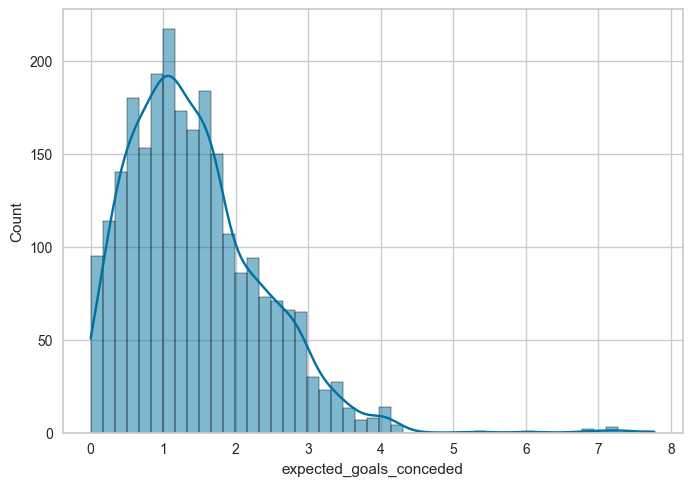

In [86]:


sns.histplot(play_data['expected_goals_conceded'], kde=True)
plt.show()


In [87]:
import numpy as np

corr = play_data.corr()['expected_goals_conceded'].sort_values(ascending=False)
# print(corr.head(20))
corr #.tail(20)


expected_goals_conceded      1.000000
influence                    0.262502
expected_goals_conceded_5    0.202487
expected_goals_conceded_3    0.162042
goals_conceded_5             0.150279
                               ...   
xP_3                        -0.115046
clean_sheets_5              -0.128060
was_home                    -0.200322
pts_bps                     -0.231481
penalties_missed_1                NaN
Name: expected_goals_conceded, Length: 67, dtype: float64

<Axes: ylabel='expected_goals_conceded'>

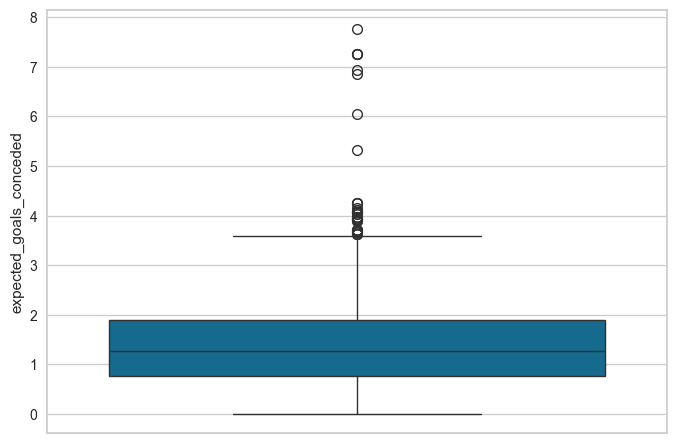

In [88]:
sns.boxplot(play_data['expected_goals_conceded'])


In [89]:
g_xgc_data= data[(data['minutes_5'] >= 60) & (data['position'].isin(['GK', 'DEF']))]
g_xgc_data.drop(columns=['position'], inplace=True)

In [ ]:

g_xgc_data['gw'] = g_xgc_data['round']
g_xgc_data['team'] = g_xgc_data['player_team']
g_xgc_data['opponent_team'] = g_xgc_data.apply(lambda row: row['a_team'] if row['was_home'] == 1 else row['h_team'], axis=1)
g_xgc_data[['h_team', 'a_team', 'was_home', 'team', 'opponent_team', 'player_team', 'gw', 'round']]


sum_features = [
    'creativity', 'influence', 'threat',
    'expected_goals_1', 'expected_assists_1', 'expected_goal_involvements_1',
    'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1',
    'shots_1', 'key_passes_1', 'npg_1', 'npxG_1',
]

mean_features = [
    'value', 'ict_index', 'selected', 'transfers_in', 'transfers_out'
]

# max_features = [
#     'minutes_1', 'influence'
# ]

identity_features = [
    'whh', 'whd', 'wha',    # bookmaker odds
    'was_home',
    'opponent_team'
]


,h_team,a_team,was_home,team,opponent_team,player_team,gw,round
22,Newcastle United,Brentford,False,Brentford,Newcastle United,Brentford,5,5
23,Brentford,Everton,True,Brentford,Everton,Brentford,6,6
24,Nottingham Forest,Brentford,False,Brentford,Nottingham Forest,Brentford,7,7
25,Manchester United,Brentford,False,Brentford,Manchester United,Brentford,8,8
26,Chelsea,Brentford,False,Brentford,Chelsea,Brentford,10,10
...,...,...,...,...,...,...,...,...
11284,Chelsea,Manchester United,True,Chelsea,Manchester United,Chelsea,31,31
11285,Sheffield United,Chelsea,False,Chelsea,Sheffield United,Chelsea,32,32
11286,Chelsea,Everton,True,Chelsea,Everton,Chelsea,33,33
11287,Arsenal,Chelsea,False,Chelsea,Arsenal,Chelsea,34,34


In [ ]:
team_df = g_xgc_data.groupby(['team', 'gw']).agg({
    **{f: 'sum' for f in sum_features},
    **{f: 'mean' for f in mean_features},
    # **{f: 'max' for f in max_features},
    **{f: 'first' for f in identity_features}
}).reset_index()

for col in ['expected_goals_conceded_1','goals_conceded_1','goals_scored_1']:
    team_df[f'{col}_3'] = team_df.groupby('team')[col].rolling(3, min_periods=1).mean().reset_index(0, drop=True)
    team_df[f'{col}_5'] = team_df.groupby('team')[col].rolling(5, min_periods=1).mean().reset_index(0, drop=True)


team_df = team_df.rename(columns={
    'creativity': 'team_creativity',
    'influence': 'team_influence',
    'threat': 'team_threat',
    'expected_goals_1': 'team_expected_goals',
    'expected_assists_1': 'team_expected_assists',
    'expected_goal_involvements_1': 'team_expected_goal_involvements',
    'expected_goals_conceded_1': 'team_expected_goals_conceded',
    'goals_conceded_1': 'team_goals_conceded',
    'goals_scored_1': 'team_goals_scored',
    'shots_1': 'team_shots',
    'attempted_passes_1': 'team_attempted_passes',
    'key_passes_1': 'team_key_passes',
    'npg_1': 'team_npg',
    'npxG_1': 'team_npxG',
    'value': 'team_value',
    'ict_index': 'team_ict_index',
    'selected': 'team_selected',
    'transfers_in': 'team_transfers_in',
    'transfers_out': 'team_transfers_out',
    'whh': 'team_whh',
    'whd': 'team_whd',
    'wha': 'team_wha',
    'was_home': 'team_was_home',
    'expected_goals_conceded_1_3': 'team_expected_goals_conceded_3',
    'expected_goals_conceded_1_5': 'team_expected_goals_conceded_5',
    'goals_conceded_1_3': 'team_goals_conceded_3',
    'goals_conceded_1_5': 'team_goals_conceded_5',
    'goals_scored_1_3': 'team_goals_scored_3',
    'goals_scored_1_5': 'team_goals_scored_5',

    })


team_df = team_df.rename(columns={
    'creativity': 'team_creativity',
    'influence': 'team_influence',
    'threat': 'team_threat',
    'expected_goals_1': 'team_expected_goals',
    'expected_assists_1': 'team_expected_assists',
    'expected_goal_involvements_1': 'team_expected_goal_involvements',
    'expected_goals_conceded_1': 'team_expected_goals_conceded',
    'goals_conceded_1': 'team_goals_conceded',
    'goals_scored_1': 'team_goals_scored',
    'shots_1': 'team_shots',
    'attempted_passes_1': 'team_attempted_passes',
    'key_passes_1': 'team_key_passes',
    'npg_1': 'team_npg',
    'npxG_1': 'team_npxG',
    'value': 'team_value',
    'ict_index': 'team_ict_index',
    'selected': 'team_selected',
    'transfers_in': 'team_transfers_in',
    'transfers_out': 'team_transfers_out',
    'whh': 'team_whh',
    'whd': 'team_whd',
    'wha': 'team_wha',
    'was_home': 'team_was_home',
    'expected_goals_conceded_1_3': 'team_expected_goals_conceded_3',
    'expected_goals_conceded_1_5': 'team_expected_goals_conceded_5',
    'goals_conceded_1_3': 'team_goals_conceded_3',
    'goals_conceded_1_5': 'team_goals_conceded_5',
    'goals_scored_1_3': 'team_goals_scored_3',
    'goals_scored_1_5': 'team_goals_scored_5',

    })

opponent_stats = team_df[['team', 'gw','team_ict_index', 'team_expected_goals', 'team_expected_assists', 'team_goals_scored', 'team_shots', 'team_npxG', 'team_value',
                          'team_whh', 'team_whd', 'team_wha', 'team_expected_goals_conceded_3', 'team_expected_goals_conceded_5', 'team_goals_conceded_3', 'team_goals_conceded_5',
                          'team_goals_scored_3', 'team_goals_scored_5']].rename(

                columns={'team': 'opponent_team', 'team_ict_index':'opponent_ict','team_expected_goals': 'opponent_xG', 'team_expected_assists': 'opponent_xA',
                        'team_goals_scored': 'opponent_goals_scored', 'team_shots': 'opponent_shots', 'team_npxG': 'opponent_npxG', 'team_value': 'opponent_value',
                        'team_whh': 'opponent_whh', 'team_whd': 'opponent_whd', 'team_wha': 'opponent_wha', 'team_expected_goals_conceded_3': 'opponent_xgc_3',
                        'team_expected_goals_conceded_5': 'opponent_xgc_5', 'team_goals_conceded_3': 'opponent_gc_3', 'team_goals_conceded_5': 'opponent_gc_5',
                        'team_goals_scored_3': 'opponent_goals_scored_3', 'team_goals_scored_5': 'opponent_goals_scored_5'
                        })

# opponent_stats
# 2. Merge this back into the original dataframe matching on 'opponent_team' and 'gw'
team_df = team_df.merge(opponent_stats, on=['opponent_team', 'gw'], how='left')

final_df = g_xgc_data.merge(team_df, on=['team', 'gw'], how='left')


In [97]:
cols = [ 'expected_goals_conceded', 'creativity','ict_index', 'influence','selected',  'threat', 'transfers_balance', 'transfers_in', 'transfers_out', 'value', 'was_home',
        'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'pts_bps', 'whh', 'whd', 'wha', 'team_creativity', 'team_influence',
        'team_threat', 'team_expected_goals', 'team_expected_assists', 'team_expected_goal_involvements', 'team_expected_goals_conceded', 'team_goals_conceded', 'team_goals_scored',
         'team_shots', 'team_key_passes', 'team_npg', 'team_npxG', 'team_value', 'team_ict_index', 'team_selected','team_transfers_in', 'team_transfers_out', 'team_whh', 'team_whd',
         'team_wha',

        'opponent_xgc_3', 'opponent_xgc_5', 'opponent_gc_3', 'opponent_gc_5', 'opponent_goals_scored_3', 'opponent_goals_scored_5', 'team_was_home', 'opponent_ict', 'opponent_xG',
        'opponent_xA', 'opponent_goals_scored', 'opponent_shots', 'opponent_npxG', 'opponent_value', 'opponent_whh', 'opponent_whd', 'opponent_wha',

        'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
        'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_missed_1', 'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
        'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1',  'assists_y_1', 'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',
        'xP_1',

        'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3',
        'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
        'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3',  'assists_y_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',
        'xP_3',

        'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5',
        'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
        'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5',  'assists_y_5', 'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',
        'xP_5',

        ]

In [98]:
xgc_df = final_df[cols].copy()
xgc_df = xgc_df.dropna().reset_index(drop=True)

scaler = StandardScaler()
scaler.fit(xgc_df.drop(columns=['expected_goals_conceded']))
joblib.dump(scaler, './models/xgc_scaler_xgc.pkl')  # Save fitted scaler

xgc_data_scaled = pd.DataFrame(scaler.transform(xgc_df.drop(columns=['expected_goals_conceded'])),
                                columns=xgc_df.drop(columns=['expected_goals_conceded']).columns)

xgc_scaled_df = pd.concat([xgc_data_scaled, xgc_df[['expected_goals_conceded']]], axis=1)


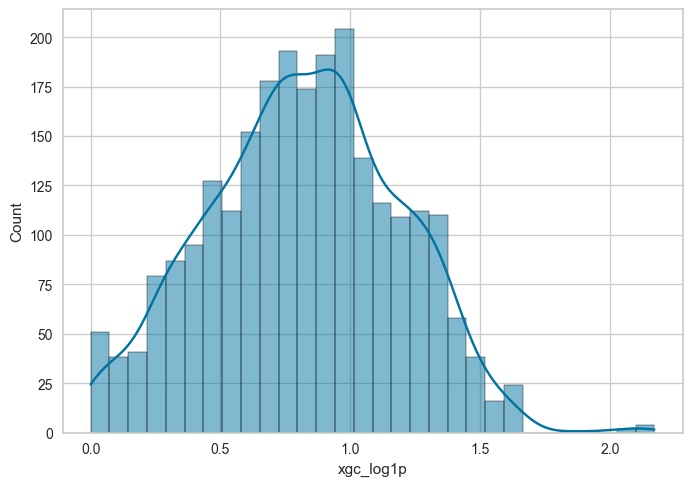

In [99]:

xgc_scaled_df['xgc_log1p'] = np.log1p(xgc_scaled_df['expected_goals_conceded'])

xgc_model_data = xgc_scaled_df.copy()
xgc_model_data.drop(columns=['expected_goals_conceded'], inplace=True)

sns.histplot(xgc_scaled_df['xgc_log1p'] , kde=True)
plt.show()


In [100]:
import numpy as np

corr = xgc_model_data.corr()['xgc_log1p'].sort_values(ascending=False)
# print(corr.head(20))
corr #.tail(20)


xgc_log1p             1.000000
influence             0.283091
opponent_value        0.273162
team_influence        0.256187
opponent_ict          0.253477
                        ...   
was_home             -0.198456
pts_bps              -0.219412
penalties_missed_1         NaN
penalties_missed_3         NaN
penalties_missed_5         NaN
Name: xgc_log1p, Length: 156, dtype: float64

In [101]:
reg = setup(
    data=xgc_model_data,
    target='xgc_log1p',
    session_id=42,
    ignore_features=['element', 'player_name'],  # drop IDs
    remove_multicollinearity=True,
    transform_target=True,
)

best = compare_models(n_select=3)


,Description,Value
0,Session id,42
1,Target,xgc_log1p
2,Target type,Regression
3,Original data shape,"(2452, 156)"
4,Transformed data shape,"(2452, 123)"
5,Transformed train set shape,"(1716, 123)"
6,Transformed test set shape,"(736, 123)"
7,Ignore features,2
8,Numeric features,155
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.1526,0.0456,0.2128,0.6702,0.1273,0.5238,2.4460
lightgbm,Light Gradient Boosting Machine,0.1647,0.0494,0.2216,0.6413,0.1293,0.4790,0.6650
xgboost,Extreme Gradient Boosting,0.1683,0.0520,0.2275,0.6234,0.1334,0.4866,0.8520
rf,Random Forest Regressor,0.1768,0.0556,0.2349,0.5986,0.1378,0.5614,3.9290
gbr,Gradient Boosting Regressor,0.1960,0.0618,0.2479,0.5528,0.1440,0.5570,1.3350
ada,AdaBoost Regressor,0.2405,0.0856,0.2921,0.3800,0.1700,0.7352,0.7870
br,Bayesian Ridge,0.2316,0.0869,0.2942,0.3730,0.1712,0.7136,0.2320
omp,Orthogonal Matching Pursuit,0.2344,0.0879,0.2959,0.3654,0.1720,0.7090,0.2600
ridge,Ridge Regression,0.2331,0.0885,0.2969,0.3610,0.1729,0.7088,0.2790
lr,Linear Regression,0.2343,0.0889,0.2976,0.3582,0.1735,0.7124,1.5110


In [102]:
blender = blend_models(best, optimize='MAE')
tuned = tune_model(blender) # br	Bayesian Ridge	0.5527	0.5437	0.7312	%0.3223	0.2966	0.9471


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.1615,0.0512,0.2263,0.6880,0.1358,0.6843
1,0.1426,0.0392,0.1979,0.6573,0.1140,0.2772
2,0.1442,0.0366,0.1914,0.7413,0.1162,0.4534
3,0.1416,0.0360,0.1898,0.7521,0.1173,0.5760
4,0.1754,0.0582,0.2412,0.6194,0.1380,0.3676
5,0.1468,0.0392,0.1980,0.6936,0.1190,0.4582
6,0.1471,0.0435,0.2086,0.6081,0.1263,0.7873
7,0.1419,0.0433,0.2081,0.6747,0.1218,0.3093
8,0.1525,0.0444,0.2107,0.7064,0.1198,0.4156


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [103]:
tuned

VotingRegressor(estimators=[('Extra Trees Regressor',
                             ExtraTreesRegressor(n_jobs=-1, random_state=42)),
                            ('Light Gradient Boosting Machine',
                             LGBMRegressor(n_jobs=-1, random_state=42)),
                            ('Extreme Gradient Boosting',
                             XGBRegressor(base_score=None, booster='gbtree',
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device='cpu',
                                          early_sto...
                                          learning_rate=None, max_bin=None,
                                          max_cat_threshold=None,
                                          max_cat_to_onehot=None,
                                          max_delta_step=None, max_depth=None,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=-1,
                                          num_parallel_tree=None,
                                          random_state=42, ...))],
                n_jobs=-1,
                weights=[0.6900000000000001, 0.48000000000000004,
                         0.35000000000000003])

In [104]:
for attr in dir(tuned):
    try:
        v = getattr(tuned, attr)
        if isinstance(v, np.ndarray):
            setattr(tuned, attr, v.copy())   # copy makes it writeable
    except:
        pass

In [105]:
# finalize_model can fail if some numpy arrays inside the model object are
# read-only. Recursively replace readonly numpy arrays with writable copies
# before calling finalize_model.

def _make_writeable_recursive(obj, _seen=None):
	"""
	Recursively walk the object and replace any numpy.ndarray that is not
	writeable with a writeable copy. Handles dict, list/tuple/set and object
	attributes. Keeps a seen set to avoid infinite recursion on circular refs.
	"""
	if _seen is None:
		_seen = set()
	oid = id(obj)
	if oid in _seen:
		return obj
	_seen.add(oid)

	try:
		# numpy was imported earlier in the notebook as `np`
		if isinstance(obj, np.ndarray):
			if not obj.flags.writeable:
				return np.array(obj, copy=True)
			return obj

		if isinstance(obj, dict):
			for k, v in list(obj.items()):
				obj[k] = _make_writeable_recursive(v, _seen)
			return obj

		if isinstance(obj, (list, tuple, set)):
			new_items = [_make_writeable_recursive(x, _seen) for x in obj]
			try:
				return type(obj)(new_items)
			except Exception:
				return new_items

		# For generic objects, attempt to iterate attributes and replace in-place
		for attr in dir(obj):
			if attr.startswith('__'):
				continue
			try:
				v = getattr(obj, attr)
			except Exception:
				continue
			new_v = _make_writeable_recursive(v, _seen)
			if new_v is not v:
				try:
					setattr(obj, attr, new_v)
				except Exception:
					# ignore attributes that can't be set
					pass

	except Exception:
		# be conservative: if anything unexpected happens, just return original object
		return obj

	return obj


# Make the tuned model writable-safe before finalizing
_make_writeable_recursive(tuned)

final_blender = finalize_model(tuned)

ValueError: cannot set WRITEABLE flag to True of this array

In [108]:
final_blender

NameError: name 'final_blender' is not defined

### Save Model


In [107]:
xgc_final_model = tuned # finalize_model(final_blender)
save_model(xgc_final_model, './models/xgc_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('target_transformation',
                  TransformerWrapperWithInverse(transformer=TargetTransformer(estimator=PowerTransformer(standardize=False)))),
                 ('numerical_imputer',
                  TransformerWrapper(include=['creativity', 'ict_index',
                                              'influence', 'selected', 'threat',
                                              'transfers_balance',
                                              'transfers_in', 'transfers_out',
                                              'value', 'was_h...
                                                            learning_rate=None,
                                                            max_bin=None,
                                                            max_cat_threshold=None,
                                                            max_cat_to_onehot=None,
                                                            max